In [1]:
from CASP16_NA_assessment import *
# global (capatalized variables) are defined in there
# %matplotlib inline

# this encompasses getting sets of interactions from each model and comparing these sets
# eg base-pairs or A-minor interactions

secstruct_location = '../raw_scores/secondary_structure/'

# this is not scored in secondary structure analysis -- eg will have only 37 for motif and secondary structure
interactions_not_scores = ['D1273']

TARGETS = MONOMER_TARGETS_TO_SCORETEMP
[TARGETS.remove(target) for target in interactions_not_scores]
print(len(TARGETS)) # 37!

print(len(TEMPLATE_TARGETS),len(NO_TEMPLATE_TARGETS),len(MSA_TARGETS),len(NO_MSA_TARGETS))


35
19 18 23 16


100%|█████████████████| 10/10 [00:00<00:00, 57.21it/s]


  group           motif_type        F1
0   272    TANDEM_GA_SHEARED  0.071429
1   272               Z_TURN  0.137605
2   272               T_LOOP  0.197129
3   272  INTERCALATED_T_LOOP  0.254272
4   272          TL_RECEPTOR  0.325700
['272' '238' '052' '450' '063' '294' '304' '028' '481' '167' '241' '110'
 '435' '208' '033' '462' '235' '369' '183' '417' '338' '286' '006' '189'
 '231' '159' '325' '317' '448' '267' '156' '306' '094']


/tmp/ipykernel_21794/2536476200.py:60: UserWarning: FixedFormatter should only be used together with FixedLocator
  t=ax.set_yticklabels(labels=ax.get_yticklabels(),size=tick_label_size)
/tmp/ipykernel_21794/2536476200.py:61: UserWarning: FixedFormatter should only be used together with FixedLocator
  t=ax.set_xticklabels(labels=ax.get_xticklabels(),size=tick_label_size*1.2)


"            \n    num_bootstrap=0,group_col='gr_code',h_bar_color='grey',color_by='motif',\n           best1_df[best1_df.target.isin(TEMPLATE_TARGETS)],'Z_CASP16_t30_g30_l40',\n              targets_to_choose_best=TARGETS_CHOOSE_BEST,\n           N=N,ax=axes[0,0],height=height,\n          color='grey',tick_label_size=tick_label_size,\n               num_bootstrap=num_bootstrap))\n\n\n plot_heat_map(df_summed,score,\n                     figsize=(4,4),\n                    cbar_label='F1 all base pairs',ticklabel_size=4,group_col='group',\n                    savefig=f'figure_subpanels/heatmap_motif_bymotif_{score}_{rank_type}',\n                        rank_type=rank_type,vmin=0,vmax=1,y_text_size=4,\n                         num_bootstrap=10,target_col='motif_type',\n                         target_order = motif_order)"

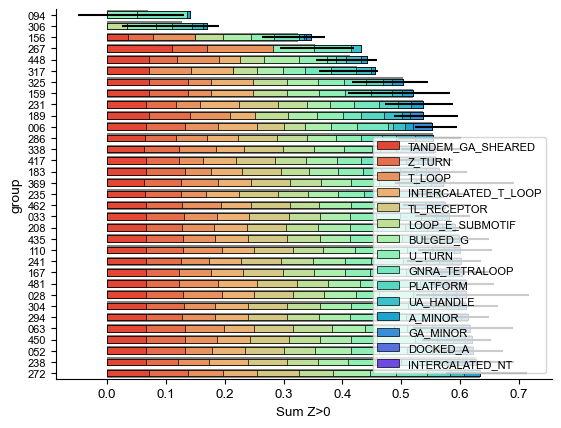

In [68]:
def plot_top_n_(df,score,targets_to_choose_best,N,ax,tick_label_size=8,
    num_bootstrap=0,group_col='gr_code',h_bar_color='grey',color_by=None,
               target_col='target',order_color=None,palette=None,rank_type =None,
               alpha=1,weights=[]):
    df_copy = df.copy()
    
    #group_score = get_group_score(df_copy,score=score,targets_to_choose_best=targets_to_choose_best)
    #group_score["tie"] = get_group_score(df_copy,agg="mean",score=score,targets_to_choose_best=targets_to_choose_best)[score]
    #top_n = group_score.sort_values(score, ascending=False).head(N)
    #rank_order = top_n.gr_code.values

    if "Z_" == score[:2]:
        group_score,score_boot = get_group_score_bootstrap(df_copy,score=score,
            targets_to_choose_best=targets_to_choose_best,group_col=group_col,
            n_bootstraps=num_bootstrap,target_col=target_col)
    elif rank_type == 'sum':
        group_score,score_boot = get_group_score_bootstrap(df_copy, agg="sum", score=score,
                    targets_to_choose_best=targets_to_choose_best,group_col=group_col,
                   fill_nan=1,fill_not_present=0,
                   n_bootstraps=num_bootstrap,target_col=target_col)
    elif rank_type == 'mean':
        group_score,score_boot = get_group_score_bootstrap(df_copy, agg="mean", score=score, # mean ignores nans so if 6 values, 2 nan, will noramlize sum by 4
                    targets_to_choose_best=targets_to_choose_best,group_col=group_col,
                   fill_nan=np.nan,fill_not_present=0,
                   n_bootstraps=num_bootstrap,target_col=target_col)
    elif rank_type == 'weighted_mean':
        group_score,score_boot = get_group_score_bootstrap(df_copy, agg="weighted_mean", score=score, # mean ignores nans so if 6 values, 2 nan, will noramlize sum by 4
                    targets_to_choose_best=targets_to_choose_best,group_col=group_col,
                   fill_nan=np.nan,fill_not_present=0,
                   n_bootstraps=num_bootstrap,target_col=target_col,weights=weigts)
    else:
        group_score,score_boot = get_group_score_bootstrap(df_copy,score=score,agg='sum',
            targets_to_choose_best=targets_to_choose_best,
                   n_bootstraps=num_bootstrap,target_col=target_col)
    
    group_score = group_score.reset_index().sort_values(score, ascending=False)
    rank_order = group_score[group_col].values

    #rank_order = group_score.sort_values(score, ascending=True).gr_code.values
    plot_fig = df_copy[df_copy[group_col].isin(rank_order)].copy()

    ci = calc_ci_limits(group_score.set_index(group_col).reindex(rank_order)[score],score_boot[f'q20_{score}'],score_boot[f'q80_{score}'])
    ax.barh(rank_order[:N],width=group_score.set_index(group_col).reindex(rank_order)[score][:N],
            color=h_bar_color,xerr=[c[:N] for c in ci],alpha=alpha) #score_boot[f'sem_{score}'].to_list()
    if color_by:
        # assume scores is 1D
        #preds_top1_sorted = preds_top1.sort_values(color_by, key=lambda x: pd.Categorical(x, categories=order_color, ordered=True))
        df_copy[group_col] = pd.Categorical(df_copy[group_col],ordered=True,categories=rank_order[::1])
        #df_copy[score] = df_copy[score].fillna(1)
        df_cumsum = df_copy.groupby([group_col,color_by])[score].mean().unstack()[order_color].apply(lambda x: x.cumsum() / sum(~x.isna()), axis=1).stack().reset_index()
        df_cumsum.rename(columns={0: score}, inplace=True)

        print(df_cumsum.head())
        print(rank_order)
        sns.barplot(df_cumsum,x=score,y='group',dodge=False,#order=rank_order[::-1],
                hue=color_by,hue_order=order_color[::-1],palette=palette,legend=True,
                linewidth=0.5, edgecolor="black",width=0.6,ax=ax) # ,
        handles, labels = ax.get_legend_handles_labels()
        legend = ax.legend(handles[::-1], labels[::-1], title=None, loc='lower right', fontsize=8)
    
    ax.set_xlabel("Sum Z>0",size=tick_label_size*1.2)
    ax.invert_yaxis()
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    t=ax.set_yticklabels(labels=ax.get_yticklabels(),size=tick_label_size)
    t=ax.set_xticklabels(labels=ax.get_xticklabels(),size=tick_label_size*1.2)
    group_score = group_score.set_index(group_col)
    if 'AF3-server - 304' in group_score.index:
        # Plot AF3 baseline
        x_coord = group_score[score]['AF3-server - 304'] 
        ax.axvline(x=x_coord, color='gold', linestyle='--', linewidth=1, label='AF3-server - 304')
    return rank_order

df_summed =preds_top1.groupby(['motif_type','group']).F1.mean().reset_index()
fig,ax = plt.subplots(1,1)
plot_top_n_(df_summed,score,targets_to_choose_best=TARGETS_CHOOSE_BEST,
            N=1000,ax=ax,color_by='motif_type',target_col='motif_type',group_col='group',
           order_color=motif_order,palette="rainbow",num_bootstrap=10,rank_type = 'mean', #'weighted_mean',
            #weights = native_motif_counts,
           alpha=1)

'''            
    num_bootstrap=0,group_col='gr_code',h_bar_color='grey',color_by='motif',
           best1_df[best1_df.target.isin(TEMPLATE_TARGETS)],'Z_CASP16_t30_g30_l40',
              targets_to_choose_best=TARGETS_CHOOSE_BEST,
           N=N,ax=axes[0,0],height=height,
          color='grey',tick_label_size=tick_label_size,
               num_bootstrap=num_bootstrap))


 plot_heat_map(df_summed,score,
                     figsize=(4,4),
                    cbar_label='F1 all base pairs',ticklabel_size=4,group_col='group',
                    savefig=f'figure_subpanels/heatmap_motif_bymotif_{score}_{rank_type}',
                        rank_type=rank_type,vmin=0,vmax=1,y_text_size=4,
                         num_bootstrap=10,target_col='motif_type',
                         target_order = motif_order)'''

In [31]:
df_summed

,motif_type,group,F1
0,A_MINOR,006,0.211640
1,A_MINOR,028,0.251046
2,A_MINOR,033,0.331439
3,A_MINOR,052,0.286995
4,A_MINOR,063,0.297222
...,...,...,...
475,Z_TURN,435,0.944444
476,Z_TURN,448,0.666667
477,Z_TURN,450,1.000000
478,Z_TURN,462,0.912281


# Read Inputs secondary structure

In [3]:
# get all native information

# TODO check bp ordering, should not matter...
# so should order every pair by number in chain

native_bp_lists = {}
native_crosspairs = {}
native_singlets = {}
native_dbs = {}
data = []
for target in TARGETS:
    print(target)
    df = pd.read_csv(f'{secstruct_location}base_pair_tables_monomer/{target}_combined_dssr_data_canonical.csv') # _with_AH_AF3

    # find native
    natives = [gr for gr in df.folder.unique() if gr[0]!='R' and gr[0]!='_'] # print(natives)

    #  for monomer analysis I need to onyl take same chain interactions from R1283v3 an dR1283v3
    # most fair to just take chain 0 as we did with other targets
    if 'R1283' in target:
        df = df[(df.nt1.str.startswith('0.')) &  (df.nt1.str.startswith('0.'))]

    bp_lists = []
    for native in natives:
        print(native)
        # TODO there is no 3,305, it 4 205 where is 3 coming from??
        bp_list = df[df.folder == native].apply(parse_base_pair_dssr,axis=1).to_list()
        bp_lists.append(bp_list)
    native_bp_lists[target] = bp_lists
    native_singlets[target],native_crosspairs[target] = get_crossed_singlets(bp_lists,target,nt_num_only=False,verbose=True)
    if 'R1283' in target:
        target_name = 'R1283v1'
    else: target_name = target
    target_len = TARGET_INFO[TARGET_INFO.Target==target_name]['Length RNA (nt)'].item()
    native_dbs[target] = [convert_bp_list_to_dotbracket(x,target_len,offset=-1,full_nt_naming=True) for x in bp_lists]


R1203
native_R1203v1
native_R1203v2
R1205
native_R1205
R1209
native_R1209
R1211
native_R1211_update
native_R1211
native_R1211_preliminary
R1212
native_R1212
R1221s2
native_R1221s2
R1221s3
native_R1221s3
R1224s2
native_R1224s2
R1224s3
native_R1224s3
R1241
native_R1241_corrected_renumbere
R1242
native_R1242
R1248
native_R1248
R1250
native_R1250
R1251
native_R1251
R1252
native_R1252
R1253v1
native_R1253v1
R1253v2
native_R1253v2
R1254
native_R1254
R1255
native_R1255_7
native_R1255_8
native_R1255_4
native_R1255_6
native_R1255_10
native_R1255_9
native_R1255_1
native_R1255_5
native_R1255_3
native_R1255_2
R1256
native_R1256_16
native_R1256_9
native_R1256_27
native_R1256_3
native_R1256_13
native_R1256_30
native_R1256_7
native_R1256_4
native_R1256_10
native_R1256_20
native_R1256_21
native_R1256_25
native_R1256_28
native_R1256_14
native_R1256_19
native_R1256_11
native_R1256_12
native_R1256_23
native_R1256_5
native_R1256_29
native_R1256_18
native_R1256_15
native_R1256_22
native_R1256_17
native_R12

In [5]:
# get all NON CONINCAL native information

native_bp_lists_NC = {}
for target in TARGETS:
    print(target)
    df = pd.read_csv(f'{secstruct_location}base_pair_tables_monomer/{target}_combined_dssr_data.csv') # _with_AH_AF3
    natives = [gr for gr in df.folder.unique() if gr[0]!='R' and gr[0]!='_'] # print(natives)
    
    num_native_total = len(df[df.folder.isin(natives)])
    num_pred_total = len(df[~df.folder.isin(natives)])
    df = df[~df.name.isin(['WC','Wobble'])]
    num_native_nc = len(df[df.folder.isin(natives)])
    num_pred_nc = len(df[~df.folder.isin(natives)])
    print(num_native_nc/num_native_total)
    print(num_pred_nc/num_pred_total)
    


    # TODO for monomer analysis I need to onyl take same chain interactions from R1283v3 an dR1283v3
    # most fair to just take chain 0 as we did with other targets
    if 'R1283' in target:
        df = df[(df.nt1.str.startswith('0.')) &  (df.nt1.str.startswith('0.'))]

    bp_lists = []
    for native in natives:
        print(native)
        bp_list = df[df.folder == native].apply(parse_base_pair_dssr,axis=1).to_list()
        bp_lists.append(bp_list)
    native_bp_lists_NC[target] = bp_lists


R1203
0.23275862068965517
0.285049504950495
native_R1203v1
native_R1203v2
R1205
0.3076923076923077
0.3128299894403379
native_R1205
R1209
0.10344827586206896
0.2301623425883781
native_R1209
R1211
0.21212121212121213
0.19165824794342617
native_R1211_update
native_R1211
native_R1211_preliminary
R1212
0.08695652173913043
0.28623452294246177
native_R1212
R1221s2
0.3485714285714286
0.38204648677531394
native_R1221s2
R1221s3
0.3333333333333333
0.39186937687437523
native_R1221s3
R1224s2
0.34065934065934067
0.3433487019215893
native_R1224s2
R1224s3
0.3333333333333333
0.3877147635700167
native_R1224s3
R1241
0.3427230046948357
0.34934161695576876
native_R1241_corrected_renumbere
R1242
0.39325842696629215
0.39497329563305056
native_R1242
R1248
0.4461538461538462
0.28862739085438305
native_R1248
R1250
0.4075471698113208
0.31246667851430604
native_R1250
R1251
0.3323353293413174
0.2913853994367205
native_R1251
R1252
0.3719806763285024
0.32916743245726887
native_R1252
R1253v1
0.38427947598253276
0.307

In [6]:
# get number native base pairs
num_native_bp = 0
for k in native_bp_lists.keys():
    num_native_bp+=len(native_bp_lists[k][0])

num_native_singlet = 0
for k in native_singlets.keys():
    num_native_singlet+=len(native_singlets[k][0])

num_native_crossed = 0
for k in native_crosspairs.keys():
    num_native_crossed+=len(native_crosspairs[k][0])
num_native_nc = 0
for k in native_bp_lists_NC.keys():
    num_native_nc+=len(native_bp_lists_NC[k][0])

print(num_native_bp,num_native_singlet,num_native_crossed,num_native_nc)

2880 147 935 1439


In [7]:
native_dbs['R1288']

['((((((...([[((((((........))).))))]].(((((....))))).))))))']

In [10]:
# get all native information
import sys
import pickle
sys.setrecursionlimit(15000)

native_bp_lists_o = {}
native_dbs_o = {}
data_o = []
for target in MULTIMER_TARGETS:#[:1]+MULTIMER_TARGETS[2:]: # R1251 lasts...
    print(target)
    df = pd.read_csv(f'{secstruct_location}base_pair_tables_complex/{target}_combined_dssr_data_canonical.csv')

    # find native
    natives_o = [gr for gr in df.folder.unique() if gr[0]!='R'] # print(natives)

    bp_lists_o = []
    for native in natives_o:
        print(native)
        bp_list_o = df[df.folder == native].apply(parse_base_pair_dssr,axis=1).to_list()
        bp_lists_o.append(bp_list_o)
    native_bp_lists_o[target] = bp_lists_o
    if 'R1283' in target:
        target_name = 'R1283v1'
    else: target_name = target
    target_len = TARGET_INFO[TARGET_INFO.Target==target_name]['Length RNA (nt)'].item()
    print(target)
    #native_dbs_o[target] = [convert_bp_list_to_dotbracket(x,target_len,offset=-1,full_nt_naming=True) for x in bp_lists_o]


R1250
native_R1250o
R1250
R1251
native_R1251o
R1251
R1252
native_R1252o
R1252
R1253v1
native_R1253v1o
R1253v1
R1253v2
native_R1253v2o
R1253v2
R1254
native_R1254o
R1254
R1281
native_R1281o
R1281
R1283v2
native_R1283v2o
R1283v2
R1283v3
native_R1283v3o
R1283v3
R1285
native_R1285o
R1285
R1290
native_R1290o
R1290


In [11]:
native_bp_lists_o_inter = {}
for target,list_list_bps in native_bp_lists_o.items():
    new_list = []
    for bp_list in list_list_bps:
        inter_list = [[bpA,bpB] for bpA,bpB in bp_list if bpA[0]!=bpB[0]]
        if len(inter_list)>0:
            new_list.append(inter_list)
    native_bp_lists_o_inter[target]=new_list
native_bp_lists_o_inter

{'R1250': [[['0:a128', '1:u136'],
   ['0:g129', '1:c135'],
   ['0:c135', '5:g129'],
   ['0:u136', '5:a128'],
   ['1:a128', '2:u136'],
   ['1:g129', '2:c135'],
   ['2:a128', '3:u136'],
   ['2:g129', '3:c135'],
   ['3:a128', '4:u136'],
   ['3:g129', '4:c135'],
   ['4:a128', '5:u136'],
   ['4:g129', '5:c135']]],
 'R1251': [[['0:g140', '1:c146'],
   ['0:c146', '6:g140'],
   ['0:u254', '6:a413'],
   ['0:c255', '6:g412'],
   ['0:c256', '6:g411'],
   ['0:g411', '1:c256'],
   ['0:g412', '1:c255'],
   ['0:a413', '1:u254'],
   ['0:g675', '8:c676'],
   ['0:c676', '8:g675'],
   ['1:g140', '2:c146'],
   ['1:g411', '2:c256'],
   ['1:g412', '2:c255'],
   ['1:a413', '2:u254'],
   ['1:g675', '9:c676'],
   ['1:c676', '9:g675'],
   ['2:g140', '3:c146'],
   ['2:g411', '3:c256'],
   ['2:g412', '3:c255'],
   ['2:a413', '3:u254'],
   ['2:g675', 'a:c676'],
   ['2:c676', 'a:g675'],
   ['3:g140', '4:c146'],
   ['3:g411', '4:c256'],
   ['3:g412', '4:c255'],
   ['3:a413', '4:u254'],
   ['3:g675', 'b:c676'],
   ['

### save

In [13]:
# dot bracket for those that prefer it
native_dbs_o
data = []
for target, structures in native_dbs_o.items():
    for structure in structures:
        data.append({'target': target, 'secondary_structure': structure})

df = pd.DataFrame(data)
df.to_csv('summary_tables/native_SS_o_.csv', index=False)
# native_crosspairs_o['R1283v3']

In [14]:
UNRESOLVED_RESIDUES

{'R1203v1': {'start': 1, 'end': 134, 'unresolved': []},
 'R1203v2': {'start': 1, 'end': 134, 'unresolved': []},
 'R1205': {'start': 1, 'end': 55, 'unresolved': []},
 'R1209': {'start': 1, 'end': 72, 'unresolved': []},
 'R1211': {'start': 1, 'end': 90, 'unresolved': []},
 'R1211_preliminary': {'start': 1, 'end': 90, 'unresolved': []},
 'R1211_updated': {'start': 1, 'end': 90, 'unresolved': []},
 'R1212': {'start': 21,
  'end': 239,
  'unresolved': ['75',
   '76',
   '77',
   '78',
   '79',
   '80',
   '81',
   '82',
   '83',
   '84',
   '85',
   '86',
   '87',
   '88',
   '89',
   '90',
   '91',
   '92',
   '93',
   '94',
   '95',
   '96',
   '97',
   '98',
   '99',
   '100',
   '101',
   '102',
   '103',
   '104',
   '105',
   '106',
   '107',
   '108',
   '109',
   '110',
   '111',
   '112',
   '113',
   '114',
   '115',
   '116',
   '117',
   '118',
   '119',
   '120',
   '121',
   '122',
   '123',
   '124',
   '125',
   '126',
   '127',
   '128',
   '129',
   '130',
   '131',
   '13

In [16]:
# dot bracket for those that prefer it
native_dbs
data = []
for target, structures in native_dbs.items():
    for structure in structures:
        new_structure = ''
        for i,s in enumerate(structure):
            if i<UNRESOLVED_RESIDUES[target]['start']-1 or i > UNRESOLVED_RESIDUES[target]['end']-1 or str(i) in UNRESOLVED_RESIDUES[target]['unresolved']:
                new_structure += '-'
            else:
                new_structure += s
        print(len(structure),len(new_structure))
        data.append({'target': target, 'secondary_structure': new_structure})

df = pd.DataFrame(data)
df.to_csv('summary_tables/native_SS.csv', index=False)
# native_crosspairs['R1283v3']

134 134
134 134
59 59
72 72
90 90
90 90
90 90
247 247
398 398
86 86
395 395
86 86
480 480
205 205
407 407
744 744
833 833
520 520
574 574
574 574
413 413
124 124
124 124
124 124
124 124
124 124
124 124
124 124
124 124
124 124
124 124
127 127
127 127
127 127
127 127
127 127
127 127
127 127
127 127
127 127
127 127
127 127
127 127
127 127
127 127
127 127
127 127
127 127
127 127
127 127
127 127
127 127
127 127
127 127
127 127
127 127
127 127
127 127
127 127
127 127
127 127
89 89
89 89
64 64
64 64
77 77
718 718
580 580
577 577
526 526
58 58
284 284
627 627
480 480
82 82
72 72


## generate scores

In [17]:
native_bp_lists_o_inter

{'R1250': [[['0:a128', '1:u136'],
   ['0:g129', '1:c135'],
   ['0:c135', '5:g129'],
   ['0:u136', '5:a128'],
   ['1:a128', '2:u136'],
   ['1:g129', '2:c135'],
   ['2:a128', '3:u136'],
   ['2:g129', '3:c135'],
   ['3:a128', '4:u136'],
   ['3:g129', '4:c135'],
   ['4:a128', '5:u136'],
   ['4:g129', '5:c135']]],
 'R1251': [[['0:g140', '1:c146'],
   ['0:c146', '6:g140'],
   ['0:u254', '6:a413'],
   ['0:c255', '6:g412'],
   ['0:c256', '6:g411'],
   ['0:g411', '1:c256'],
   ['0:g412', '1:c255'],
   ['0:a413', '1:u254'],
   ['0:g675', '8:c676'],
   ['0:c676', '8:g675'],
   ['1:g140', '2:c146'],
   ['1:g411', '2:c256'],
   ['1:g412', '2:c255'],
   ['1:a413', '2:u254'],
   ['1:g675', '9:c676'],
   ['1:c676', '9:g675'],
   ['2:g140', '3:c146'],
   ['2:g411', '3:c256'],
   ['2:g412', '3:c255'],
   ['2:a413', '3:u254'],
   ['2:g675', 'a:c676'],
   ['2:c676', 'a:g675'],
   ['3:g140', '4:c146'],
   ['3:g411', '4:c256'],
   ['3:g412', '4:c255'],
   ['3:a413', '4:u254'],
   ['3:g675', 'b:c676'],
   ['

In [25]:
# read the secondary structure prediction for casp predictors
data = [] 
for target in MULTIMER_TARGETS:
    print(target)
    df = pd.read_csv(f'{secstruct_location}base_pair_tables_complex/{target}_combined_dssr_data_canonical.csv')
    
    # find native
    natives = [gr for gr in df.folder.unique() if gr[0]!='R']
    pred_df = df[~df.folder.isin(natives)]

    for gr,gr_df in pred_df.groupby('folder'):
        # get the sets of nts to be compared
        bp_list = gr_df.apply(parse_base_pair_dssr,axis=1).to_list()
        bp_list = [pair for pair in bp_list if not any(num in pair for num in UNRESOLVED_RESIDUES[target])]
        bp_list = [[bpA,bpB] for bpA,bpB in bp_list if bpA[0]!=bpB[0]]
        # comapre sets to native
        f1s_bp_list = compare_set_lists(native_bp_lists_o_inter[target],bp_list,target)
        recalls_bp_list = compare_set_lists(native_bp_lists_o_inter[target],bp_list,target,return_recall=True)
        precisions_bp_list = compare_set_lists(native_bp_lists_o_inter[target],bp_list,target,return_precision=True)


        # take max score over all native
        f1_bp_list = np.nan if np.any(np.isnan(f1s_bp_list)) else max(f1s_bp_list)
        recall_bp_list = np.nan if np.any(np.isnan(recalls_bp_list)) else max(recalls_bp_list)
        precision_bp_list = np.nan if np.any(np.isnan(precisions_bp_list)) else max(precisions_bp_list)
        if 'R1283' in target:
            target_name = 'R1283v1'
        else: target_name = target
        target_len = TARGET_INFO[TARGET_INFO.Target==target_name]['Length RNA (nt)'].item()

        data.append({'pred_id':gr,'target':target,
                     'bp_list':bp_list,
                     'f1s_bp_list':f1s_bp_list,'recalls_bp_list':recalls_bp_list,'precisions_bp_list':precisions_bp_list,
                     'f1_bp_list':f1_bp_list,'recall_bp_list':recall_bp_list,'precision_bp_list':precision_bp_list})
        preds = pd.DataFrame(data)
        preds['group'] = preds.pred_id.apply(lambda x: x.split('TS')[-1].split('_')[0] if 'TS' in x else x.split('LG')[-1].split('_')[0] if 'LG' in x else x)
        preds.to_parquet('summary_tables/CASP16_3Dpreds_SS_temp.parquet',index=False)
preds = pd.DataFrame(data)

preds['group'] = preds.pred_id.apply(lambda x: x.split('TS')[-1].split('_')[0] if 'TS' in x else x.split('LG')[-1].split('_')[0] if 'LG' in x else x)
preds.to_parquet('summary_tables/CASP16_3Dpreds_Ss_o.parquet',index=False)

R1250
R1251
R1252
R1253v1
R1253v2
R1254
R1281
R1283v2
R1283v3
R1285
R1290


In [26]:
native_bp_lists_o_inter

{'R1250': [[['0:a128', '1:u136'],
   ['0:g129', '1:c135'],
   ['0:c135', '5:g129'],
   ['0:u136', '5:a128'],
   ['1:a128', '2:u136'],
   ['1:g129', '2:c135'],
   ['2:a128', '3:u136'],
   ['2:g129', '3:c135'],
   ['3:a128', '4:u136'],
   ['3:g129', '4:c135'],
   ['4:a128', '5:u136'],
   ['4:g129', '5:c135']]],
 'R1251': [[['0:g140', '1:c146'],
   ['0:c146', '6:g140'],
   ['0:u254', '6:a413'],
   ['0:c255', '6:g412'],
   ['0:c256', '6:g411'],
   ['0:g411', '1:c256'],
   ['0:g412', '1:c255'],
   ['0:a413', '1:u254'],
   ['0:g675', '8:c676'],
   ['0:c676', '8:g675'],
   ['1:g140', '2:c146'],
   ['1:g411', '2:c256'],
   ['1:g412', '2:c255'],
   ['1:a413', '2:u254'],
   ['1:g675', '9:c676'],
   ['1:c676', '9:g675'],
   ['2:g140', '3:c146'],
   ['2:g411', '3:c256'],
   ['2:g412', '3:c255'],
   ['2:a413', '3:u254'],
   ['2:g675', 'a:c676'],
   ['2:c676', 'a:g675'],
   ['3:g140', '4:c146'],
   ['3:g411', '4:c256'],
   ['3:g412', '4:c255'],
   ['3:a413', '4:u254'],
   ['3:g675', 'b:c676'],
   ['

In [28]:
# read the secondary structure prediction from msa-free + DL based predictors

# previously combined pred = pd.read_csv(f'{secstruct_location}ss_score_results/{target}_ss_predictors.csv')
# adding a column of target

ss_preds =[]
incorrect_len = []
combined_df = []

all_preds = pd.read_csv(f'{secstruct_location}/combined_secondary_structure_prediction_algorithmns_rck_edited.csv')

for target in TARGETS:
    pred = all_preds[all_preds.target==target]
    #pred = pd.read_csv(f'{secstruct_location}ss_score_results/{target}_ss_predictors.csv')
    
    print(target,len(pred))
    # clean up remove & and x
    #pred['pred_structure_orig'] = pred.pred_structure.copy()
    #pred['pred_structure'] = pred.pred_structure.str.replace('&', '', regex=False).str.replace('x', '', regex=False)
    #pred.fillna({'pred_structure': ''}, inplace=True)
    #pred['target']=target
    #combined_df.append(pred)
    # all need to be same length   
    
    # I successfully corrected all errors in the secondary strcuture predictors!
    incorrect = pred[pred.pred_structure.apply(lambda x: pd.isna(x) or len(x) != len(native_dbs[target][0]))].copy()
    print(target,len(incorrect))
    incorrect['target'] = target
    incorrect['len_native'] = len(native_dbs[target][0])
    incorrect['len_orig'] = incorrect.pred_structure_orig.str.len()
    incorrect['len_cleaned'] = incorrect.pred_structure.str.len()
    incorrect_len.append(incorrect)    
    pred = pred[~(pred.pred_structure.apply(lambda x: pd.isna(x) or len(x) != len(native_dbs[target][0])))]

    # get the sets to be compared
    pred['bp_list'],pred['singlet'],pred['cross_pairs'] = zip(*pred.pred_structure.apply(lambda stuct: get_bp_lists(stuct,target,single_struct=True,offset=1)))
    # shujun dot bracket are off by one
    pred['bp_list']
    
    # score the sets against native
    pred['f1s_bp_list'] = pred.bp_list.apply(lambda bp_list: compare_set_lists(native_bp_lists[target],bp_list,target))
    
    pred['recalls_bp_list'] = pred.bp_list.apply(lambda bp_list: compare_set_lists(native_bp_lists[target],bp_list,target,return_recall=True))
    pred['precisions_bp_list'] = pred.bp_list.apply(lambda bp_list: compare_set_lists(native_bp_lists[target],bp_list,target,return_precision=True))

    pred['f1s_singlet'] = pred.singlet.apply(lambda singlet: compare_set_lists(native_singlets[target],singlet,target))
    pred['f1s_crossed'] = pred.cross_pairs.apply(lambda cross_pairs: compare_set_lists(native_crosspairs[target],cross_pairs,target))
    pred['recalls_singlets_as_bp'] = pred.bp_list.apply(lambda bp_list: compare_set_lists(native_singlets[target],bp_list,target,return_recall=True))

    # take max
    pred['f1_bp_list'] = pred.f1s_bp_list.apply(lambda x: np.nan if np.any(np.isnan(x)) else max(x))
    pred['recall_bp_list'] = pred.recalls_bp_list.apply(lambda x: np.nan if np.any(np.isnan(x)) else max(x))
    pred['precision_bp_list'] = pred.precisions_bp_list.apply(lambda x: np.nan if np.any(np.isnan(x)) else max(x))

    pred['f1_singlet'] = pred.f1s_singlet.apply(lambda x: np.nan if np.any(np.isnan(x)) else max(x))
    pred['f1_crossed'] = pred.f1s_crossed.apply(lambda x: np.nan if np.any(np.isnan(x)) else max(x))
    pred['recall_singlets_as_bp'] = pred.recalls_singlets_as_bp.apply(lambda x: np.nan if np.any(np.isnan(x)) else max(x))
    pred['target'] = target
    ss_preds.append(pred)
ss_preds = pd.concat(ss_preds)
ss_preds['group'] = ss_preds.pred_id.apply(lambda x: x.split('TS')[-1].split('_')[0] if 'TS' in x else x.split('LG')[-1].split('_')[0] if 'LG' in x else x)
ss_preds.to_parquet('summary_tables/CASP16_2Dpreds_SS.parquet',index=False)
if len(pd.concat(incorrect_len))==0:
    print('OK!')
else:
    pd.concat(incorrect_len).to_csv(f'incorrect_length_db.csv',index=False)
#pd.concat(combined_df).to_csv(f'{secstruct_location}/combined_secondary_structure_prediction_algorithmns_rck_edited.csv',index=False)


R1203 20
R1203 0
R1205 20
R1205 0
R1209 20
R1209 0
R1211 20
R1211 0
R1212 20
R1212 0
R1221s2 20
R1221s2 0
R1221s3 20
R1221s3 0
R1224s2 20
R1224s2 0
R1224s3 20
R1224s3 0
R1241 20
R1241 0
R1242 20
R1242 0
R1248 20
R1248 0
R1250 20
R1250 0
R1251 20
R1251 0
R1252 20
R1252 0
R1253v1 20
R1253v1 0
R1253v2 20
R1253v2 0
R1254 20
R1254 0
R1255 20
R1255 0
R1256 20
R1256 0
R1261 20
R1261 0
R1262 20
R1262 0
R1263 20
R1263 0
R1264 20
R1264 0
R1271 20
R1271 0
R1281 20
R1281 0
R1283v1 20
R1283v1 0
R1285 20
R1285 0
R1286 20
R1286 0
R1288 20
R1288 0
R1289 20
R1289 0
R1290 20
R1290 0
R1291 20
R1291 0
R1293 20
R1293 0
R1296 20
R1296 0
OK!


In [30]:
# read the secondary structure prediction for casp predictors
data = []
for target in TARGETS:
    print(target)
    df = pd.read_csv(f'{secstruct_location}base_pair_tables_monomer_with_AH_AF3/{target}_combined_dssr_data_canonical.csv')
    
    # find native
    natives = [gr for gr in df.folder.unique() if gr[0]!='R']
    pred_df = df[~df.folder.isin(natives)]
    # !!!!!!!! careful on the indexing, it is one off of casp numbering !!!

    for gr,gr_df in pred_df.groupby('folder'):
        # get the sets of nts to be compared
        bp_list = gr_df.apply(parse_base_pair_dssr,axis=1).to_list()
        bp_list = [pair for pair in bp_list if not any(num in pair for num in UNRESOLVED_RESIDUES[target])]
        singlets,crossed = get_crossed_singlets(bp_list,target,single_struct=True,nt_num_only=False)

        # comapre sets to native
        f1s_bp_list = compare_set_lists(native_bp_lists[target],bp_list,target)
        recalls_bp_list = compare_set_lists(native_bp_lists[target],bp_list,target,return_recall=True)
        precisions_bp_list = compare_set_lists(native_bp_lists[target],bp_list,target,return_precision=True)

        f1s_singlet = compare_set_lists(native_singlets[target],singlets,target)
        f1s_crossed = compare_set_lists(native_crosspairs[target],crossed,target)
        recalls_singlets_as_bp = compare_set_lists(native_singlets[target],bp_list,target,return_recall=True)

        # take max score over all native
        # TODO nan should be preferred???
        f1_bp_list = np.nan if np.any(np.isnan(f1s_bp_list)) else max(f1s_bp_list)
        recall_bp_list = np.nan if np.any(np.isnan(recalls_bp_list)) else max(recalls_bp_list)
        precision_bp_list = np.nan if np.any(np.isnan(precisions_bp_list)) else max(precisions_bp_list)
        f1_singlet = np.nan if np.any(np.isnan(f1s_singlet)) else max(f1s_singlet)
        f1_crossed = np.nan if np.any(np.isnan(f1s_crossed)) else max(f1s_crossed)
        recall_singlets_as_bp =  np.nan if np.any(np.isnan(recalls_singlets_as_bp)) else max(recalls_singlets_as_bp)
        if 'R1283' in target:
            target_name = 'R1283v1'
        else: target_name = target
        target_len = TARGET_INFO[TARGET_INFO.Target==target_name]['Length RNA (nt)'].item()

        data.append({'pred_id':gr,'target':target,'dot_bracket_structure':convert_bp_list_to_dotbracket(bp_list,target_len,offset=-1,full_nt_naming=True),
                     'bp_list':bp_list,'singlets':singlets,'crossed':crossed,
                     'f1s_bp_list':f1s_bp_list,'recalls_bp_list':recalls_bp_list,'precisions_bp_list':precisions_bp_list,
                     'f1s_singlet':f1s_singlet,'f1s_crossed':f1s_crossed,'recalls_singlets_as_bp':recalls_singlets_as_bp,
                     'f1_bp_list':f1_bp_list,'recall_bp_list':recall_bp_list,'precision_bp_list':precision_bp_list,
                     'f1_singlet':f1_singlet,'f1_crossed':f1_crossed,'recall_singlets_as_bp':recall_singlets_as_bp})
        preds = pd.DataFrame(data)

        preds['group'] = preds.pred_id.apply(lambda x: x.split('TS')[-1].split('_')[0] if 'TS' in x else x.split('LG')[-1].split('_')[0] if 'LG' in x else x)
        preds.to_parquet('summary_tables/CASP16_3Dpreds_SS_temp.parquet',index=False)
preds = pd.DataFrame(data)

preds['group'] = preds.pred_id.apply(lambda x: x.split('TS')[-1].split('_')[0] if 'TS' in x else x.split('LG')[-1].split('_')[0] if 'LG' in x else x)
preds.to_parquet('summary_tables/CASP16_3Dpreds_SS.parquet',index=False)

R1203
R1205
R1209
R1211
R1212
R1221s2
R1221s3
R1224s2
R1224s3
R1241
R1242
R1248
R1250
R1251
R1252
R1253v1
R1253v2
R1254
R1255
R1256
R1261
R1262
R1263
R1264
R1271
R1281
R1283v1
R1285
R1286
R1288
R1289
R1290
R1291
R1293
R1296


In [31]:
def fromat_bp_for_table(res_lists):
    rt_st = ''
    current_res = []
    for i,res_list in enumerate(res_lists):
        to_add = ''
        
        for ress in res_list:
            to_add += "-".join([t.split(':')[-1] for t in ress])
            to_add += ', '
        if to_add in current_res:
            continue
        if i>0:
            rt_st+='\n'
        current_res.append(to_add[:-2])
        rt_st += to_add[:-2]
            
        
    return rt_st[:-1]
native_bp_lists_NC

pd.Series(native_bp_lists_NC).apply(fromat_bp_for_table).to_csv('temp.csv')
                #.T.rename(columns={'0':x}).apply(get_table_format,axis=1))
#pd.concat(temp,axis=1,join='outer').sort_index().to_csv('temp.csv')

In [32]:
native_bp_lists_NC

{'R1203': [[['0:u8', '0:a14'],
   ['0:u8', '0:a21'],
   ['0:a9', '0:a23'],
   ['0:g10', '0:g103'],
   ['0:a14', '0:a21'],
   ['0:g15', '0:c106'],
   ['0:g18', '0:u113'],
   ['0:g19', '0:u20'],
   ['0:g22', '0:g104'],
   ['0:a26', '0:g102'],
   ['0:g40', '0:g64'],
   ['0:g70', '0:u90'],
   ['0:u112', '0:a116']],
  [['0:u8', '0:a14'],
   ['0:u8', '0:a21'],
   ['0:a9', '0:a23'],
   ['0:g10', '0:g103'],
   ['0:a14', '0:a21'],
   ['0:g15', '0:c106'],
   ['0:g18', '0:u113'],
   ['0:g19', '0:u20'],
   ['0:g22', '0:g104'],
   ['0:a26', '0:g102'],
   ['0:g39', '0:g64'],
   ['0:g40', '0:g63'],
   ['0:g40', '0:g64'],
   ['0:u112', '0:a116']]],
 'R1205': [[['0:a5', '0:g26'],
   ['0:a5', '0:a42'],
   ['0:a13', '0:g52'],
   ['0:u24', '0:a31'],
   ['0:u25', '0:a29'],
   ['0:u25', '0:a42'],
   ['0:g27', '0:c41'],
   ['0:a29', '0:g43']]],
 'R1209': [[['0:g10', '0:g39'], ['0:g13', '0:a31'], ['0:a51', '0:a54']]],
 'R1211': [[['0:u20', '0:c26'],
   ['0:a22', '0:c24'],
   ['0:a40', '0:c56'],
   ['0:a40', '

In [33]:
# read the secondary structure prediction for casp predictors
# use LW if want to contrain to same edge, but for now do not  
data =[]
for target in TARGETS:
    print(target)
    df = pd.read_csv(f'{secstruct_location}base_pair_tables_monomer_with_AH_AF3/{target}_combined_dssr_data.csv')
    df = df[~df.name.isin(['WC','Wobble'])]
    
    # find native
    natives = [gr for gr in df.folder.unique() if gr[0]!='R']
    pred_df = df[~df.folder.isin(natives)]

    for gr,gr_df in pred_df.groupby('folder'):
        # get the sets of nts to be compared
        bp_list = gr_df.apply(parse_base_pair_dssr,axis=1).to_list()
        bp_list = [pair for pair in bp_list if not any(num in pair for num in UNRESOLVED_RESIDUES[target])]

        # comapre sets to native
        f1s_bp_list = compare_set_lists(native_bp_lists_NC[target],bp_list,target)
        recalls_bp_list = compare_set_lists(native_bp_lists_NC[target],bp_list,target,return_recall=True)
        precisions_bp_list = compare_set_lists(native_bp_lists_NC[target],bp_list,target,return_precision=True)


        # take max score over all native
        f1_bp_list = np.nan if np.any(np.isnan(f1s_bp_list)) else max(f1s_bp_list)
        recall_bp_list = np.nan if np.any(np.isnan(recalls_bp_list)) else max(recalls_bp_list)
        precision_bp_list = np.nan if np.any(np.isnan(precisions_bp_list)) else max(precisions_bp_list)
        if 'R1283' in target:
            target_name = 'R1283v1'
        else: target_name = target
        target_len = TARGET_INFO[TARGET_INFO.Target==target_name]['Length RNA (nt)'].item()

        data.append({'pred_id':gr,'target':target,
                     'bp_list':bp_list,
                     'f1s_bp_list':f1s_bp_list,'recalls_bp_list':recalls_bp_list,'precisions_bp_list':precisions_bp_list,
                     'f1_bp_list':f1_bp_list,'recall_bp_list':recall_bp_list,'precision_bp_list':precision_bp_list,
                    })

preds_NC = pd.DataFrame(data)

preds_NC['group'] = preds_NC.pred_id.apply(lambda x: x.split('TS')[-1].split('_')[0] if 'TS' in x else x.split('LG')[-1].split('_')[0] if 'LG' in x else x)
preds_NC.to_parquet('summary_tables/CASP16_3Dpreds_SS_NC.parquet',index=False)

R1203
R1205
R1209
R1211
R1212
R1221s2
R1221s3
R1224s2
R1224s3
R1241
R1242
R1248
R1250
R1251
R1252
R1253v1
R1253v2
R1254
R1255
R1256
R1261
R1262
R1263
R1264
R1271
R1281
R1283v1
R1285
R1286
R1288
R1289
R1290
R1291
R1293
R1296


## OR read scores already made

In [ ]:
preds = pd.read_parquet('summary_tables/CASP16_3Dpreds_SS.parquet')
ss_preds = pd.read_parquet('summary_tables/CASP16_2Dpreds_SS.parquet')


ss_names = {'Test10':"RibonanzaNet Train Semisupervised", 'Test10_w_test':"RibonanzaNet Train+test Semisupervised", 'Test12':"RibonanzaNet Train", 
           'contrafold2_PRED':"CONTRAfold",'eternafold_PRED':"EternaFold",
       'contrafold_2.HN_PRED':"Linear sum assignment with CONTRAfold", 'contrafold_2.TK_PRED':"ThreshKnot with CONTRAfold",
       'eternafold.HN_PRED':"Linear sum assignment with EternaFold", 'eternafold.TK_PRED':"ThreshKnot with EternaFold", 
            'rnastructure_PRED':"RNAstructure", 'spotrna_PRED':"SPOT-RNA", 'vienna2_PRED':"ViennaRNA",
       'vienna_2.HN_PRED':"Linear sum assignment with ViennaRNA", 'vienna_2.TK_PRED':"ThreshKnot with ViennaRNA",
       'hotknots_PRED':"HotKnots", 'ipknots_PRED':"IPknot", 'knotty_PRED':"Knotty", 
            'nupack_pk_PRED':"NUPACK",'pknots_PRED':"pknots" }
ss_preds['group'] = ss_preds.group.map(ss_names)


# a check for RD that indeed nan are scores above other scores
# TOOD why this not run with RD AH 999 998
#preds_with_one_nan_in_list = preds[preds.f1s_crossed.apply(lambda x: any(pd.isna(i) for i in x))]
#ss_preds_with_one_nan_in_list = ss_preds[ss_preds.f1s_crossed.apply(lambda x: any(pd.isna(i) for i in x))]
#print(preds_with_one_nan_in_list['f1_crossed'].isna().all())
#print(ss_preds_with_one_nan_in_list['f1_crossed'].isna().all())

columns_rename_2d_to_3D = {'pred_structure':'dot_bracket_structure',	
                        'singlet':'singlets',
                        'cross_pairs':'crossed'}
columns_to_drop_2d = ['global_F1', 'crossed_pair_F1','pred_structure_orig']
columns_to_drop_for_scores = ['pred_id', 'dot_bracket_structure', 'bp_list', 'singlets', 'crossed',
       'f1s_bp_list', 'recalls_bp_list', 'precisions_bp_list', 'f1s_singlet',
       'f1s_crossed', 'recalls_singlets_as_bp']
all_preds = pd.concat([ss_preds.drop(columns=columns_to_drop_2d).rename(columns=columns_rename_2d_to_3D),preds])
all_preds['group'] = all_preds.group.apply(lambda x: GR_CODE_TO_NAME_SERVER[x] if x in GR_CODE_TO_NAME_SERVER else x)#apply(lambda x: GROUP_DICT[x] + ' - ' + x if x in GROUP_DICT else x)

all_preds.head()

In [ ]:
o_preds = pd.read_parquet('summary_tables/CASP16_3Dpreds_Ss_o.parquet')

preds_top1_o = reduce_df(o_preds,
                       static_columns=['target','group'],
                       metric_dict=SS_METRICS2,
                      participipation_cutoff=PARTICIPATION_RATE,
                       participation_score='f1_bp_list',
                      participation_targets=MULTIMER_TARGETS)
                       #.groupby(['target','group']).max().reset_index()
#preds_top1_o['group'] = preds_top1_o.group.map(GR_CODE_TO_NAME_SERVER)
preds_top1_o['group'] = preds_top1_o.group.apply(lambda x: GR_CODE_TO_NAME_SERVER[x] if x in GR_CODE_TO_NAME_SERVER else x)
preds_top1_o.head()

In [ ]:
preds_NC = pd.read_parquet('summary_tables/CASP16_3Dpreds_SS_NC.parquet')
preds_NC['group'] = preds_NC.group.apply(lambda x: GR_CODE_TO_NAME_SERVER[x] if x in GR_CODE_TO_NAME_SERVER else x)#.group.apply(lambda x: GROUP_DICT[x] + ' - ' + x if x in GROUP_DICT else x)
preds_top1_NC = reduce_df(preds_NC,
                       static_columns=['target','group'],
                       metric_dict=SS_METRICS2,
                      participipation_cutoff=PARTICIPATION_RATE,
                       participation_score='f1_bp_list',
                      participation_targets=TARGETS)
                       #.groupby(['target','group']).max().reset_index()
preds_top1_NC.head()

In [ ]:
for rank_type in ['mean']:#['sum','mean']: 
    for score,cmap in zip(['f1_bp_list'],['seismic']):#['Blues']): #zip(['f1_bp_list', 'f1_crossed','f1_singlet' ],['Greens', 'Oranges', 'Purples']):
        nc_order_to_combine = plot_heat_map(preds_top1_NC,score,
                     figsize=(4,4),cmap=cmap,
                    cbar_label='F1 non-conincal base pairs',ticklabel_size=4,group_col='group',
                    savefig=f'figure_subpanels/heatmap_{score}nc_{rank_type}',
                        rank_type=rank_type,vmin=0,vmax=1,y_text_size=4,
                             num_bootstrap=1000)

In [ ]:
preds_top1_NC.to_csv('summary_tables/ss_nc_performance.csv')

In [ ]:
nc_order_to_combine[1].to_csv('summary_tables/ss_nc_performancesumm.csv')

In [ ]:
o_order = plot_heat_map(preds_top1_o,'f1_bp_list',
                     figsize=(3,3),cmap='seismic_r',
                    cbar_label='F1 intermolecular base pairs',ticklabel_size=6,group_col='group',
                    savefig=f'figure_subpanels/heatmap_intermolecular_mean',
                        rank_type='mean',vmin=0,vmax=1,y_text_size=6,
                             num_bootstrap=1000)

In [ ]:
o_order = plot_heat_map(preds_top1_o,'precision_bp_list',
                     figsize=(3,3),cmap='seismic_r',
                    cbar_label='F1 intermolecular base pairs',ticklabel_size=6,group_col='group',
                    savefig=f'figure_subpanels/heatmap_intermolecular_prec_mean',
                        rank_type='mean',vmin=0,vmax=1,y_text_size=6,
                             num_bootstrap=1000)

In [ ]:
o_order = plot_heat_map(preds_top1_o,'recall_bp_list',
                     figsize=(3,3),cmap='seismic_r',
                    cbar_label='F1 intermolecular base pairs',ticklabel_size=6,group_col='group',
                    savefig=f'figure_subpanels/heatmap_intermolecular_recall_mean',
                        rank_type='mean',vmin=0,vmax=1,y_text_size=6,
                             num_bootstrap=1000)

In [ ]:
sns.scatterplot(preds_top1_o,x='recall_bp_list',y='precision_bp_list')

In [ ]:
# get best score for every target for every group

preds_top1 = reduce_df(all_preds.drop(columns=columns_to_drop_for_scores),
                       static_columns=['target','group'],
                       metric_dict=SS_METRICS,
                      participipation_cutoff=PARTICIPATION_RATE,
                       participation_score='f1_bp_list',
                      participation_targets=TARGETS)
                       #.groupby(['target','group']).max().reset_index()
preds_top1.head()

## Plot and rank secondary structure

## Brief aside to help SH out

In [30]:
ss_preds[(ss_preds.target=='R1288') & (ss_preds.pred_id=='spotrna_PRED')].bp_list.item()

array([array([ 1, 58]), array([ 2, 57]), array([ 3, 56]), array([ 4, 55]),
       array([ 5, 54]), array([ 6, 53]), array([16, 29]), array([17, 28]),
       array([18, 27]), array([19, 26]), array([20, 25]), array([37, 52]),
       array([38, 51]), array([39, 50]), array([40, 49]), array([41, 48]),
       array([42, 47])], dtype=object)

In [34]:
ss_preds[(ss_preds.target=='R1288') & (ss_preds.pred_id=='spotrna_PRED')].f1_bp_list

544    0.756757
Name: f1_bp_list, dtype: float64

In [29]:
native_bp_lists['R1288']

[[['0:g1', '0:c58'],
  ['0:g2', '0:c57'],
  ['0:a3', '0:u56'],
  ['0:g4', '0:c55'],
  ['0:u5', '0:a54'],
  ['0:c6', '0:g53'],
  ['0:g10', '0:c34'],
  ['0:c11', '0:g36'],
  ['0:u12', '0:a35'],
  ['0:c13', '0:g33'],
  ['0:a14', '0:u32'],
  ['0:g15', '0:c31'],
  ['0:g16', '0:c29'],
  ['0:g17', '0:c28'],
  ['0:c18', '0:g27'],
  ['0:c38', '0:g51'],
  ['0:a39', '0:u50'],
  ['0:g40', '0:c49'],
  ['0:u41', '0:a48'],
  ['0:c42', '0:g47']]]

## Brief aside to confirm scoring to RD

In [15]:
preds_top1[preds_top1.target=='R1288'][['group','f1_crossed','target']].sort_values('f1_crossed')[38:]

,group,f1_crossed,target
1690,dfr,0.000000,R1288
1691,OpenComplex,0.000000,R1288
1692,GuangzhouRNA-human,0.000000,R1288
1693,MULTICOM_ligand,0.000000,R1288
1707,GuangzhouRNA_AI,0.000000,R1288
1694,falcon2,0.000000,R1288
1696,B-LAB,0.000000,R1288
1697,isyslab-hust,0.000000,R1288
1698,BRIQX,0.000000,R1288
1699,elofsson,0.000000,R1288


In [16]:
preds_top1[preds_top1.target=='R1212'][['group','f1_crossed','target']].sort_values('f1_crossed')[38:]

,group,f1_crossed,target
250,RNApolis,0.956522,R1212
299,ipknots_PRED,0.960000,R1212
290,Test10_w_test,0.960000,R1212
289,Test10,0.960000,R1212
245,RNA_Dojo,0.960000,R1212
256,dfr,0.960000,R1212
273,nfRNA,0.960000,R1212
288,Vfold,1.000000,R1212
247,Diff,1.000000,R1212
253,dMNAfold,1.000000,R1212


In [17]:
preds_top1[preds_top1.target=='R1241'][['group','f1_crossed','target']].sort_values('f1_crossed')[20:]

,group,f1_crossed,target
572,Yang-Multimer,0.731707,R1241
576,Test10_w_test,0.800000,R1241
550,B-LAB,0.806452,R1241
575,Test10,0.934307,R1241
570,dNAfold,0.934307,R1241
577,Test12,0.934307,R1241
557,CSSB_experimental,0.935252,R1241
564,GeneSilico,0.972222,R1241
539,RNApolis,0.979021,R1241
561,nfRNA,0.979021,R1241


## Back to plotting

In [19]:
all_preds.group.unique()

array(['ViennaRNA', 'CONTRAfold', 'EternaFold', 'RNAstructure',
       'HotKnots', 'IPknot', 'Knotty', 'pknots', 'SPOT-RNA', 'NUPACK',
       'ThreshKnot with ViennaRNA',
       'Linear sum assignment with ViennaRNA',
       'ThreshKnot with EternaFold',
       'Linear sum assignment with EternaFold',
       'ThreshKnot with CONTRAfold',
       'Linear sum assignment with CONTRAfold', nan,
       'RibonanzaNet Train Semisupervised', 'RibonanzaNet Train',
       'RibonanzaNet Train+test Semisupervised', 'NKRNA-s - S 028',
       'Yang-Server - S 052', 'MIEnsembles-Server - S 110',
       'SoutheRNA - 156', 'OpenComplex - 167', 'GuangzhouRNA-human - 183',
       'LCBio - 189', 'falcon2 - S 208', 'elofsson - 241', 'CoDock - 262',
       'CSSB_experimental - 286', 'KiharaLab - 294', 'AF3-server - S 304',
       'RNA_Dojo - 006', 'RNApolis - 063', 'SimRNA-server - S 094',
       '406 - 159', 'dfr - 165', 'thermomaps - 169', 'B-LAB - 231',
       'isyslab-hust - 235', 'BRIQX - 238', 'UNRES -

In [7]:
preds_top1

,target,group,f1_bp_list,recall_bp_list,precision_bp_list,recall_singlets_as_bp,f1_singlet,f1_crossed
0,R1203,406 - 159,0.967033,1.000000,0.975610,1.0,0.666667,1.0
1,R1203,AF3 w/o complex - S 998,0.967033,1.000000,0.936170,1.0,0.666667,1.0
2,R1203,"AF3 w/o complex, MSA - S 999",0.967033,1.000000,0.936170,1.0,0.666667,1.0
3,R1203,AF3-server - S 304,0.967033,1.000000,0.936170,1.0,0.666667,1.0
5,R1203,B-LAB - 231,0.967033,1.000000,1.000000,1.0,1.000000,1.0
...,...,...,...,...,...,...,...,...
2084,R1296,falcon2 - S 208,0.982456,1.000000,0.965517,1.0,0.666667,NaN
2085,R1296,isyslab-hust - 235,0.964286,0.964286,1.000000,1.0,0.666667,NaN
2086,R1296,kiharalab_server - S 267,0.697674,0.535714,1.000000,0.0,0.000000,NaN
2088,R1296,pknots,0.814815,0.785714,0.846154,0.0,0.000000,NaN


In [21]:
 preds_top1.pivot_table(index="group", columns="target", values='f1_crossed', dropna=False)


target,R1203,R1205,R1209,R1211,R1212,R1221s2,R1221s3,R1224s2,R1224s3,R1241,...,R1283v2,R1283v3,R1285,R1286,R1288,R1289,R1290,R1291,R1293,R1296
group,,,,,,,,,,,,,,,,,,,,,
405 - 325,NaN,NaN,0.000000,NaN,1.000000,0.962025,0.947368,0.954545,0.947368,0.993103,...,NaN,NaN,NaN,0.354839,NaN,NaN,NaN,0.895706,0.000000,NaN
406 - 159,1.000000,0.648649,0.000000,NaN,1.000000,0.962025,0.947368,0.954545,0.947368,0.993103,...,NaN,NaN,NaN,0.354839,NaN,NaN,NaN,0.895706,0.000000,NaN
AF3 w/o complex - S 998,1.000000,0.648649,0.000000,NaN,1.000000,0.962025,0.947368,0.954545,0.947368,0.993103,...,NaN,NaN,NaN,0.327869,0.000000,1.000000,0.903955,0.895706,0.571429,NaN
"AF3 w/o complex, MSA - S 999",1.000000,0.648649,0.000000,NaN,1.000000,0.000000,0.947368,0.692308,0.947368,0.290909,...,NaN,NaN,NaN,0.000000,0.000000,0.357143,0.403226,0.235294,0.571429,NaN
AF3-server - S 304,1.000000,0.666667,0.000000,NaN,1.000000,0.962025,0.947368,0.954545,0.947368,0.993103,...,NaN,NaN,NaN,0.338983,0.000000,1.000000,0.842105,0.895706,0.000000,NaN
B-LAB - 231,1.000000,0.648649,0.000000,NaN,1.000000,0.935065,0.000000,0.943820,0.947368,0.806452,...,NaN,NaN,NaN,0.327869,0.000000,1.000000,0.842105,0.895706,0.000000,NaN
BRIQX - 238,1.000000,0.578947,0.000000,NaN,1.000000,0.974359,0.947368,0.943820,0.947368,0.986301,...,NaN,NaN,NaN,NaN,0.000000,1.000000,1.000000,0.895706,0.000000,NaN
Bhattacharya - 369,1.000000,0.685714,0.000000,NaN,0.956522,0.950000,0.947368,0.933333,0.947368,0.993103,...,NaN,NaN,NaN,0.800000,0.000000,1.000000,0.898876,0.895706,0.000000,NaN
CONTRAfold,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN


In [ ]:

# Replace only the original NaN values with '-'
pivot_table = pivot_table.where(pivot_table.notna(), '-')

In [10]:
preds_top1.pivot_table(index="group",columns="target",values='f1_crossed', dropna=False,fill_value='-').loc['Vfold - 481']

target
R1203           1.0
R1205      0.647059
R1209           0.0
R1211             -
R1212           1.0
R1221s2    0.938272
R1221s3    0.947368
R1224s2    0.966292
R1224s3    0.947368
R1241      0.993103
R1242      0.972973
R1248           0.8
R1250      0.789474
R1251      0.763158
R1252      0.361702
R1253v1     0.44186
R1253v2    0.413043
R1254      0.731183
R1255             -
R1256             -
R1261           1.0
R1262           1.0
R1263             -
R1264             -
R1271             -
R1281      0.828221
R1283v1         0.0
R1283v2           -
R1283v3           -
R1285             -
R1286      0.450704
R1288           0.4
R1289           1.0
R1290           1.0
R1291      0.888889
R1293           1.0
R1296             -
Name: Vfold - 481, dtype: object

In [16]:
to_make_table

,target,group,f1_bp_list,recall_bp_list,precision_bp_list,recall_singlets_as_bp,f1_singlet,f1_crossed
0,R1203,406 - 159,0.967033,1.000000,0.975610,1.0,0.666667,1.0
1,R1203,AF3 w/o complex - S 998,0.967033,1.000000,0.936170,1.0,0.666667,1.0
2,R1203,"AF3 w/o complex, MSA - S 999",0.967033,1.000000,0.936170,1.0,0.666667,1.0
3,R1203,AF3-server - S 304,0.967033,1.000000,0.936170,1.0,0.666667,1.0
5,R1203,B-LAB - 231,0.967033,1.000000,1.000000,1.0,1.000000,1.0
...,...,...,...,...,...,...,...,...
2084,R1296,falcon2 - S 208,0.982456,1.000000,0.965517,1.0,0.666667,-
2085,R1296,isyslab-hust - 235,0.964286,0.964286,1.000000,1.0,0.666667,-
2086,R1296,kiharalab_server - S 267,0.697674,0.535714,1.000000,0.0,0.000000,-
2088,R1296,pknots,0.814815,0.785714,0.846154,0.0,0.000000,-


In [23]:
to_make_table.pivot_table(index="group",columns="target",values=score, dropna=False)

/tmp/ipykernel_18400/2709895875.py:1: FutureWarning: Dropping invalid columns in DataFrameGroupBy.mean is deprecated. In a future version, a TypeError will be raised. Before calling .mean, select only columns which should be valid for the function.
  to_make_table.pivot_table(index="group",columns="target",values=score, dropna=False)


target
group
405 - 325
406 - 159
AF3 w/o complex - S 998
"AF3 w/o complex, MSA - S 999"
AF3-server - S 304
B-LAB - 231
BRIQX - 238
Bhattacharya - 369
CONTRAfold


In [27]:
# nan means they correctely predicted no motif
ss_tables = {}
for score in SS_METRICS.keys():
    to_make_table = preds_top1.copy()
    to_make_table[score] = to_make_table[score].fillna(9999)
    table = to_make_table.pivot_table(index="group",columns="target",values=score, dropna=False)#,fill_value='-')
    table = table.replace(9999, '-')
    # correctly predicted none ==  '-' 
    # did not partipate == nan
    print('aaaaa',score,table.head())

    # score
    basic_sum = get_group_score(preds_top1, agg="sum", score=score,
                    targets_to_choose_best=TARGETS_CHOOSE_BEST,group_col='group')
    sum_reward_not_pred = get_group_score(preds_top1, agg="sum", score=score,
                    targets_to_choose_best=TARGETS_CHOOSE_BEST,group_col='group',
                   fill_nan=1,fill_not_present=0) 
    nanmean = get_group_score(preds_top1, agg="mean", score=score, # mean ignores nans so if 6 values, 2 nan, will noramlize sum by 4
                    targets_to_choose_best=TARGETS_CHOOSE_BEST,group_col='group',
                   fill_nan=np.nan,fill_not_present=0) 
    participation = get_group_score(preds_top1, agg="sum", score=score,
                    targets_to_choose_best=TARGETS_CHOOSE_BEST,group_col='group',
                   fill_nan=np.nan,fill_not_present=-100) 
    not_pred = get_group_score(preds_top1, agg="sum", score=score,
                    targets_to_choose_best=TARGETS_CHOOSE_BEST,group_col='group',
                   fill_nan=100,fill_not_present=0)

    # add total scores
    table = table.merge(sum_reward_not_pred.rename(columns={score:f'sum'}), on='group', how='left')
    table = table.merge(nanmean.rename(columns={score:f'mean'}), on='group', how='left')

    # Add ranks 
    table[f'sum_rank'] = table[f'sum'].rank(ascending=False, method='min')
    table[f'mean_rank'] = table[f'mean'].rank(ascending=False, method='min')

    print('bbbbb',table.head())


    # save total scores and rank for the template and msa grouped targets
    grouped_df = {'template': preds_top1[preds_top1.target.isin(TEMPLATE_TARGETS)],
                  'notemplate': preds_top1[preds_top1.target.isin(NO_TEMPLATE_TARGETS)],
                  'msa':  preds_top1[preds_top1.target.isin(MSA_TARGETS)],
                  'nomsa': preds_top1[preds_top1.target.isin(NO_MSA_TARGETS)]}

    for grouping, grdf in grouped_df.items():
        sum_reward_not_pred = get_group_score(grdf, agg="sum", score=score,
                    targets_to_choose_best=TARGETS_CHOOSE_BEST,group_col='group',
                   fill_nan=1,fill_not_present=0) 
        nanmean = get_group_score(grdf, agg="mean", score=score, # mean ignores nans so if 6 values, 2 nan, will noramlize sum by 4
                    targets_to_choose_best=TARGETS_CHOOSE_BEST,group_col='group',
                   fill_nan=np.nan,fill_not_present=0) 

        # add to table, also add in rank
        # add total scores
        table = table.merge(sum_reward_not_pred.rename(columns={score:f'{grouping}_sum'}), 
                                          on='group', how='left')
        table = table.merge(nanmean.rename(columns={score:f'{grouping}_mean'}), 
                            on='group', how='left')    
        # Add ranks 
        table[f'{grouping}_sum_rank'] = table[f'{grouping}_sum'].rank(ascending=False, method='min')
        table[f'{grouping}_mean_rank'] = table[f'{grouping}_mean'].rank(ascending=False, method='min')
        print(grouping,table.head())


    ss_tables[score] = table

# min_max normalize sum_reward_not_pred

# save the summary tables
for score,table in ss_tables.items():
    sort_col = [col for col in table.columns if 'sum_'==col[:4] and '_rank' == col[-5:]][0]
    table.sort_values(sort_col).to_csv(f'summary_tables/secstruct_{score}_with_rank.csv',index=False)

aaaaa f1_bp_list target                           R1203     R1205     R1209     R1211  \
group                                                                  
405 - 325                          NaN       NaN  0.884615       NaN   
406 - 159                     0.967033  0.648649  0.867925  0.970588   
AF3 w/o complex  - S 998      0.967033  0.648649  0.867925  0.985507   
AF3 w/o complex, MSA - S 999  0.967033  0.648649  0.980392  0.971429   
AF3-server - S 304            0.967033  0.666667  0.884615  0.971429   

target                           R1212   R1221s2   R1221s3   R1224s2  \
group                                                                  
405 - 325                     0.976190  0.949153  0.954545  0.951220   
406 - 159                     0.976190  0.949153  0.954545  0.951220   
AF3 w/o complex  - S 998      0.853333  0.944681  0.954545  0.963265   
AF3 w/o complex, MSA - S 999  0.864865  0.519481  0.954545  0.677966   
AF3-server - S 304            0.976190  0.9406

## some minor plots to show difference of scores

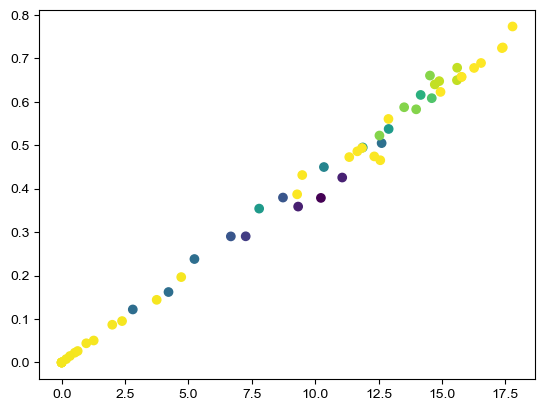

In [11]:
plt.scatter(basic_sum[score],nanmean[score],c=participation["f1_crossed"].values)

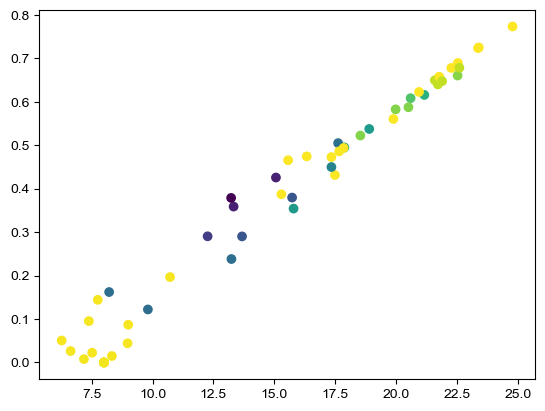

In [9]:
plt.scatter(sum_reward_not_pred["f1_crossed"],nanmean["f1_crossed"],c=participation["f1_crossed"].values)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


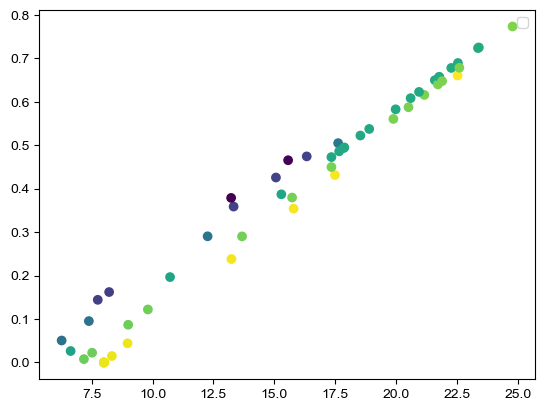

In [10]:
plt.scatter(sum_reward_not_pred["f1_crossed"],nanmean["f1_crossed"],c=not_pred["f1_crossed"].values)
plt.legend()
# we are penalizing overprediction more with sum_reward_not_pred)

## back at it

In [7]:
ss_tables['f1_bp_list']

,group,R1203,R1205,R1209,R1211,R1212,R1221s2,R1221s3,R1224s2,R1224s3,...,notemplate_sum_rank,notemplate_mean_rank,msa_sum,msa_mean,msa_sum_rank,msa_mean_rank,nomsa_sum,nomsa_mean,nomsa_sum_rank,nomsa_mean_rank
0,405 - 325,-,-,0.884615,-,0.97619,0.949153,0.954545,0.95122,0.954545,...,42.0,42.0,9.135180,0.507510,54.0,54.0,8.938977,0.744915,32.0,32.0
1,406 - 159,0.967033,0.648649,0.867925,0.970588,0.97619,0.949153,0.954545,0.95122,0.954545,...,34.0,34.0,11.072801,0.615156,46.0,46.0,9.555261,0.796272,22.0,22.0
2,AF3-server - 304,0.967033,0.666667,0.884615,0.971429,0.97619,0.940678,0.954545,0.955466,0.954545,...,4.0,4.0,16.493098,0.916283,7.0,7.0,10.442032,0.870169,9.0,9.0
3,B-LAB - 231,0.967033,0.648649,0.884615,0.971429,0.97619,0.884956,0.952381,0.955466,0.976744,...,17.0,17.0,14.411806,0.800656,23.0,23.0,10.349750,0.862479,13.0,13.0
4,BRIQX - 238,0.967033,0.578947,0.867925,1.0,0.988235,0.953191,0.954545,0.955466,0.954545,...,35.0,35.0,15.741699,0.874539,9.0,9.0,7.895416,0.657951,50.0,50.0
5,Bhattacharya - 369,0.967033,0.685714,0.884615,0.971429,0.939759,0.93617,0.954545,0.943089,0.954545,...,21.0,21.0,14.671271,0.815071,20.0,20.0,10.552968,0.879414,3.0,3.0
6,CONTRAfold,0.945055,0.545455,0.851852,0.985507,0.883117,0.681818,0.744186,0.649789,0.744186,...,22.0,22.0,13.111115,0.728395,28.0,28.0,9.485664,0.790472,25.0,25.0
7,CSSB_experimental - 286,0.953488,0.648649,0.901961,0.971429,0.902439,0.944681,0.954545,0.95935,0.954545,...,11.0,11.0,16.122541,0.895697,8.0,8.0,9.960865,0.830072,18.0,18.0
8,CoDock - 262,-,-,0.867925,0.971429,0.871795,0.801932,0.976744,0.745098,0.952381,...,45.0,45.0,9.723969,0.540221,49.0,49.0,7.912445,0.659370,49.0,49.0
9,Diff - 033,-,-,0.901961,0.970588,0.97619,0.949153,0.954545,0.951613,0.976744,...,19.0,19.0,15.595463,0.866415,12.0,12.0,9.121719,0.760143,29.0,29.0


## checking diff mean and sum, not much

/tmp/ipykernel_182219/3047871898.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = [cm.get_cmap(c)(0.4) for c in ['Greens', 'Oranges', 'Purples']]
/home/rachael/anaconda3/envs/PE/lib/python3.8/site-packages/seaborn/relational.py:438: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  points = ax.scatter(x=x, y=y, **kws)
/home/rachael/anaconda3/envs/PE/lib/python3.8/site-packages/seaborn/relational.py:438: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have

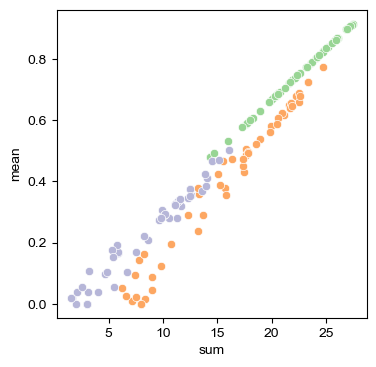

In [35]:
scores = ['f1_bp_list', 'f1_crossed','f1_singlet' ]
colors = [cm.get_cmap(c)(0.4) for c in ['Greens', 'Oranges', 'Purples']]

plt.figure(figsize=(4,4))
for score,c in zip(scores, colors):
    sns.scatterplot(ss_tables[score],x='sum',y='mean',c=c)
#plt.xlim(0,1)
#plt.ylim(0,1)

# IDEA plot the sum, but do the min/maxof the plot as the 0 and 1 point for my min max normalization -- everyone happy

/home/rachael/anaconda3/envs/PE/lib/python3.8/site-packages/seaborn/relational.py:438: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  points = ax.scatter(x=x, y=y, **kws)
/home/rachael/anaconda3/envs/PE/lib/python3.8/site-packages/seaborn/relational.py:438: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  points = ax.scatter(x=x, y=y, **kws)
/home/rachael/anaconda3/envs/PE/lib/python3.8/site-packages/seaborn/relational.py:438: U

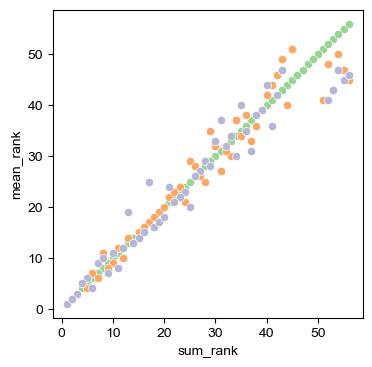

In [37]:
plt.figure(figsize=(4,4))
for score,c in zip(scores, colors):
    sns.scatterplot(ss_tables[score],x='sum_rank',y='mean_rank',c=c)

## real plots

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [01:14<00:00, 13.47it/s]
/home/rkretsch/Desktop/CASP16_NA/NA_CASP_assessment/analysis/CASP16_NA_assessment.py:1246: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_all = df_copy.pivot_table(index=group_col, columns=target_col, values=score,
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [01:11<00:00, 14.02it/s]
/home/rkretsch/Desktop/CASP16_NA/NA_CASP_assessment/analysis/CASP16_NA_assessment.py:1246: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed

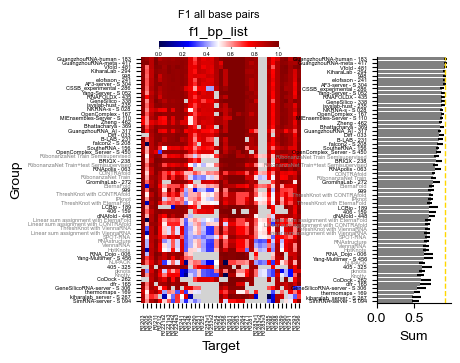

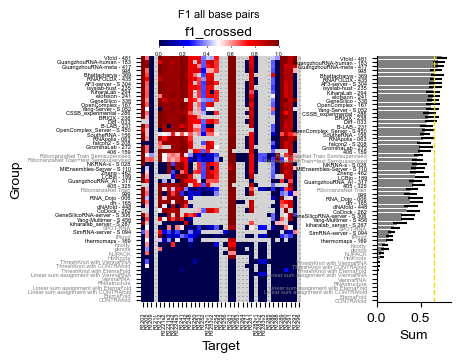

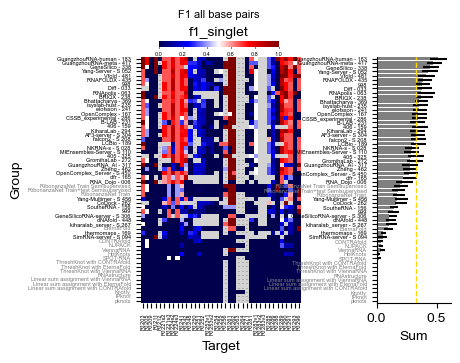

In [10]:
data_to_combine = {}

for rank_type in ['mean']: # 'sum',
    for score,cmap in zip(['f1_bp_list', 'f1_crossed','f1_singlet' ],['seismic','seismic','seismic',]):#['Greens', 'Oranges', 'Purples']):
        data_to_combine[score] = plot_heat_map(preds_top1,score,
                     figsize=(4,4),cmap=cmap,y_highlight=ss_names.values(),
                    cbar_label='F1 all base pairs',ticklabel_size=4,group_col='group',
                    savefig=f'figure_subpanels/heatmap_{score}_{rank_type}',
                        rank_type=rank_type,vmin=0,vmax=1,y_text_size=4,
                             num_bootstrap=1000)

In [21]:
data_to_combine.keys()

dict_keys(['f1_bp_list', 'f1_crossed', 'f1_singlet'])

In [22]:
nc_score = nc_order_to_combine[1]
nc_ci = nc_order_to_combine[2]
combined = []
for d,lower,upper in zip(nc_score.iterrows(),nc_ci[0],nc_ci[1]):
    group = d[0]
    score = d[1].item()
    combined.append({'score_type':'NC',
                    'group':group,
                    'score':score,
                    'lower':lower,
                    'upper':upper})
for stype, data in data_to_combine.items():
    score = data[1]
    ci = data[2]
    for d,lower,upper in zip(score.iterrows(),ci[0],ci[1]):
        group = d[0]
        score = d[1].item()
        combined.append({'score_type':stype,
                    'group':group,
                    'score':score,
                    'lower':lower,
                    'upper':upper})
combined = pd.DataFrame(combined)

/tmp/ipykernel_11982/1906212083.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = [cm.get_cmap(c)(0.4) for c in ['Greens', 'Oranges', 'Purples','Blues']]


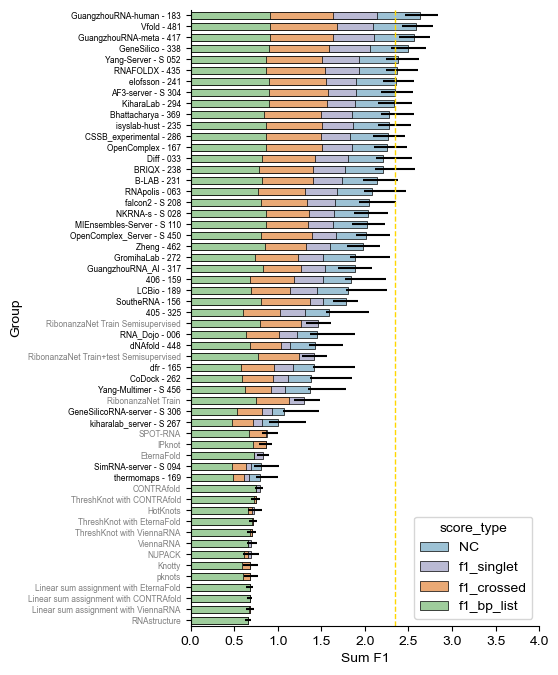

In [24]:
total_score = pd.DataFrame(combined.groupby('group').score.sum())
total_score['lower_bound'] = combined.groupby('group').lower.sum()
total_score['upper_bound'] = combined.groupby('group').upper.sum()
total_score = total_score.sort_values('score',ascending=False)
order = total_score.index

combined['score_norm'] = combined.score/4
score_type_order = ['f1_bp_list','f1_crossed','f1_singlet','NC']
combined['group'] = pd.Categorical(combined['group'], categories=order, ordered=True)
combined['score_type'] = pd.Categorical(combined['score_type'], categories=score_type_order, ordered=True)

combined = combined.sort_values(by=['group', 'score_type'])
combined['cumsum'] = combined.groupby('group')['score'].cumsum()

fig,ax = plt.subplots(1,1,figsize= (4.5,8))
ax.barh(total_score.index,width=total_score['score'], #reindex(rank_order)
            color='grey',xerr=[total_score['lower_bound'],total_score['upper_bound']],alpha=0)
colors = [cm.get_cmap(c)(0.4) for c in ['Greens', 'Oranges', 'Purples','Blues']]

sns.barplot(combined,x='cumsum',y='group',dodge=False,order=order,
                hue='score_type',palette=colors[::-1],legend=True, hue_order=score_type_order[::-1],
                linewidth=0.5, edgecolor="black",width=0.6,ax=ax)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_xlabel("Sum F1",size=10)
ax.set_ylabel("Group",size=10)
ax.set_xlim(0,4)
for label in ax.get_yticklabels():
    label.set_size(6)
    if label.get_text() in ss_names.values():
        label.set_color('grey')

x_coord = total_score['score']['AF3-server - S 304'] 
ax.axvline(x=x_coord, color='gold', linestyle='--', linewidth=1, label='AF3-server - S 304')
plt.savefig(f'figure_subpanels/ss_barplot.png',dpi=400, bbox_inches='tight')
plt.savefig(f'figure_subpanels/ss_barplot.svg',dpi=400, bbox_inches='tight')

100%|███████████████████████████████████████| 1000/1000 [00:57<00:00, 17.54it/s]
/tmp/ipykernel_11982/3279052498.py:65: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = [cm.get_cmap(c)(0.4) for c in ['Greens', 'Oranges', 'Purples','Blues']]
100%|███████████████████████████████████████| 1000/1000 [00:31<00:00, 31.85it/s]
/tmp/ipykernel_11982/3279052498.py:65: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = [cm.get_cmap(c)(0.4) for c in ['Greens', 'Oranges', 'Purples','Blues']]
100%|███████████████████████████████████████| 1000/1000 [01:07<00:00, 14.86it/s]
/tmp/ipykernel_11982/3279052498.py:65: MatplotlibDeprecationWarning: The get_cm

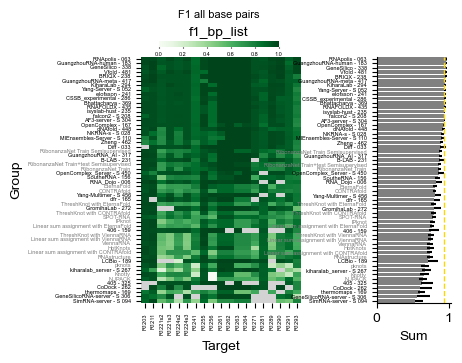

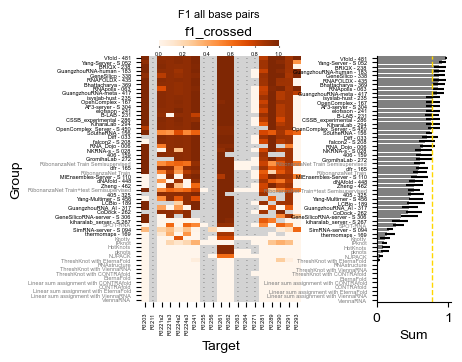

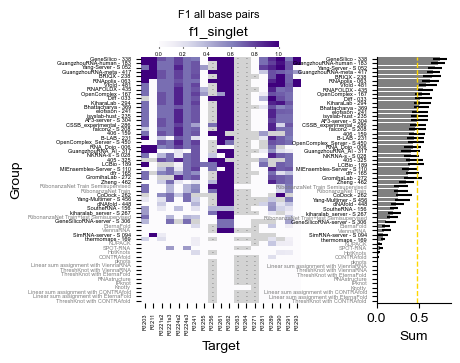

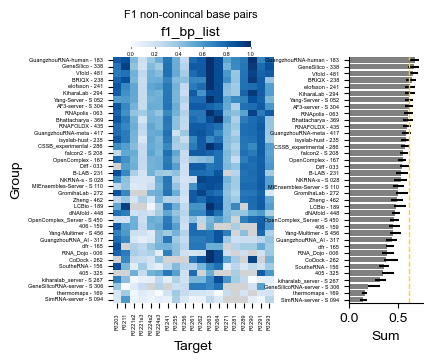

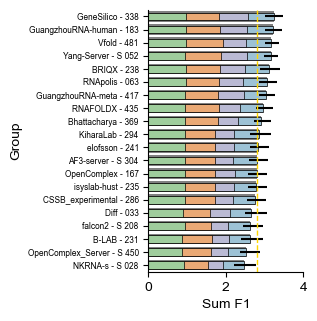

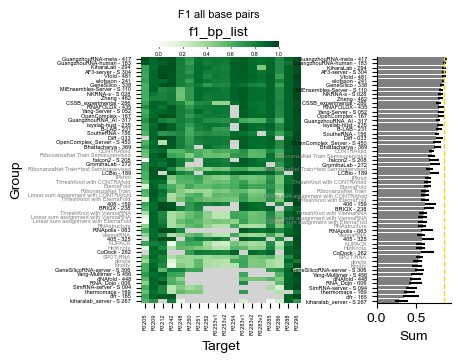

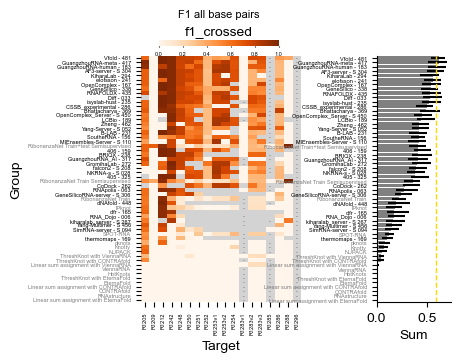

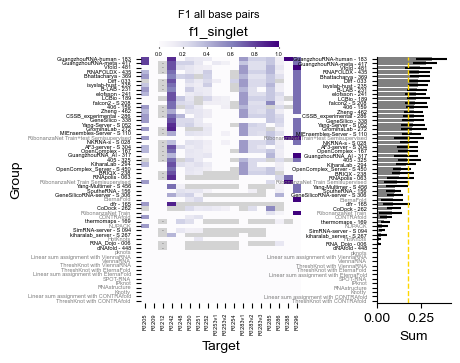

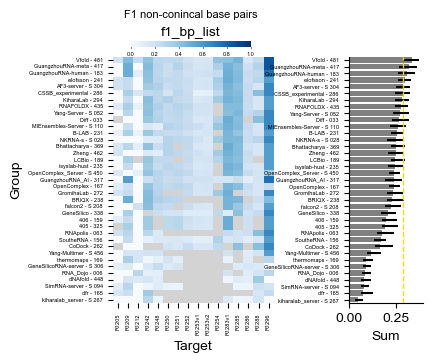

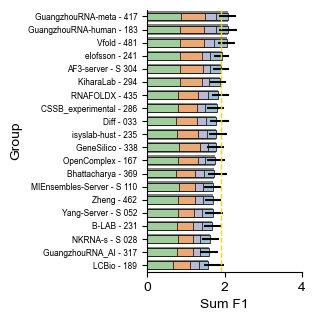

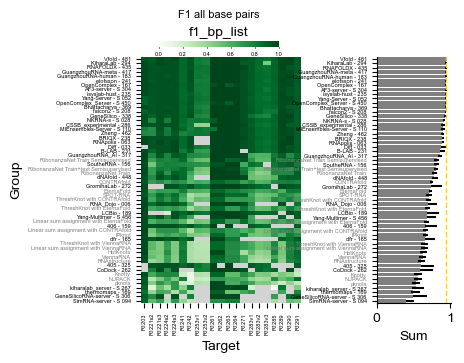

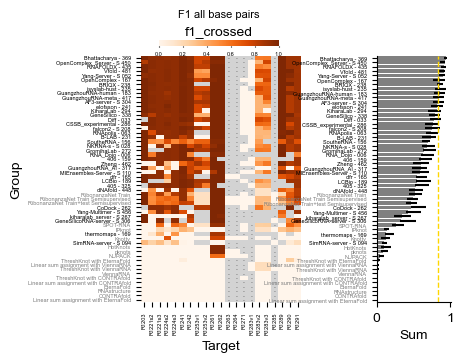

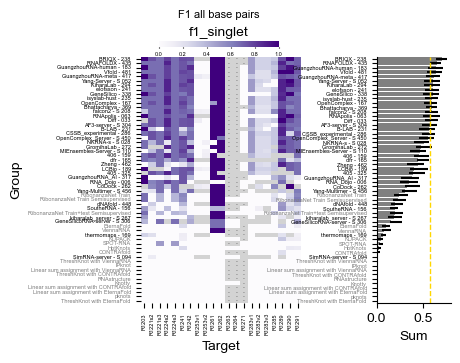

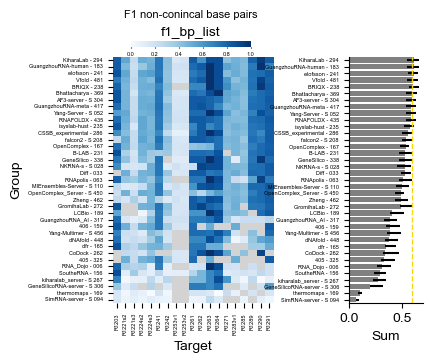

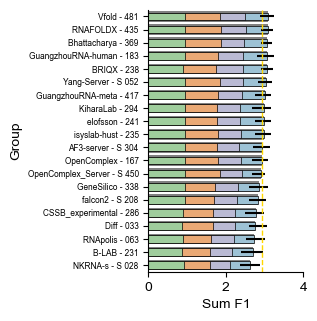

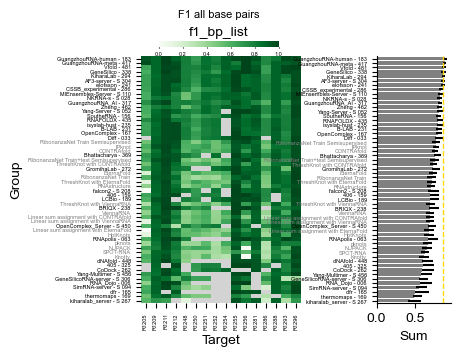

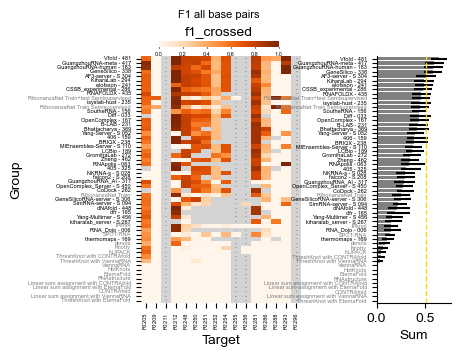

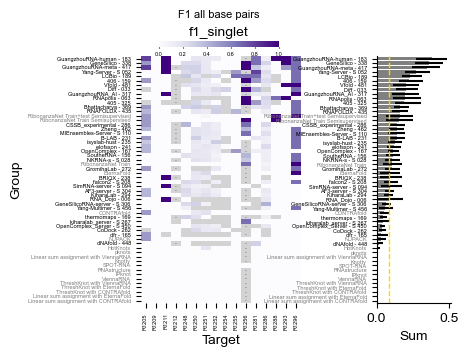

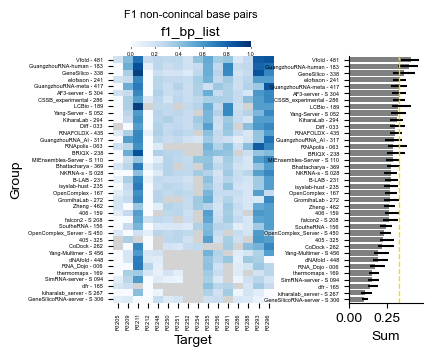

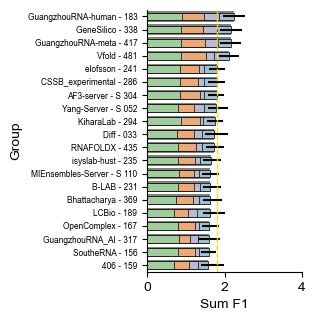

In [25]:
for plot_target,target_type in zip([TEMPLATE_TARGETS,NO_TEMPLATE_TARGETS,MSA_TARGETS,NO_MSA_TARGETS],['template','notemplate','msa','nomsa']):
    data_to_combine = {}
    
    for rank_type in ['mean']: # 'sum',
        for score,cmap in zip(['f1_bp_list', 'f1_crossed','f1_singlet' ],['Greens', 'Oranges', 'Purples']):
            data_to_combine[score] = plot_heat_map(preds_top1[preds_top1.target.isin(plot_target)],
                                                   score,
                         figsize=(4,4),cmap=cmap,y_highlight=ss_names.values(),
                        cbar_label='F1 all base pairs',ticklabel_size=4,group_col='group',
                        savefig=f'figure_subpanels/heatmap_{target_type}_{score}_{rank_type}',
                            rank_type=rank_type,vmin=0,vmax=1,y_text_size=4,
                                 num_bootstrap=1000)
    
    for rank_type in ['mean']:#['sum','mean']: 
        for score,cmap in zip(['f1_bp_list'],['Blues']): #zip(['f1_bp_list', 'f1_crossed','f1_singlet' ],['Greens', 'Oranges', 'Purples']):
            nc_order_to_combine = plot_heat_map(preds_top1_NC[preds_top1_NC.target.isin(plot_target)],
                                                score,
                         figsize=(4,4),cmap=cmap,
                        cbar_label='F1 non-conincal base pairs',ticklabel_size=4,group_col='group',
                        savefig=f'figure_subpanels/heatmap_{target_type}_{score}nc_{rank_type}',
                            rank_type=rank_type,vmin=0,vmax=1,y_text_size=4,
                                 num_bootstrap=1000)
    nc_score = nc_order_to_combine[1]
    nc_ci = nc_order_to_combine[2]
    combined = []
    for d,lower,upper in zip(nc_score.iterrows(),nc_ci[0],nc_ci[1]):
        group = d[0]
        score = d[1].item()
        combined.append({'score_type':'NC',
                        'group':group,
                        'score':score,
                        'lower':lower,
                        'upper':upper})
    for stype, data in data_to_combine.items():
        score = data[1]
        ci = data[2]
        for d,lower,upper in zip(score.iterrows(),ci[0],ci[1]):
            group = d[0]
            score = d[1].item()
            combined.append({'score_type':stype,
                        'group':group,
                        'score':score,
                        'lower':lower,
                        'upper':upper})
    combined = pd.DataFrame(combined)

    total_score = pd.DataFrame(combined.groupby('group').score.sum())
    total_score['lower_bound'] = combined.groupby('group').lower.sum()
    total_score['upper_bound'] = combined.groupby('group').upper.sum()
    total_score = total_score.sort_values('score',ascending=False)
    order = total_score.index
    
    score_type_order = ['f1_bp_list','f1_crossed','f1_singlet','NC']
    combined['group'] = pd.Categorical(combined['group'], categories=order, ordered=True)
    combined['score_type'] = pd.Categorical(combined['score_type'], categories=score_type_order, ordered=True)
    
    combined = combined.sort_values(by=['group', 'score_type'])
    combined['cumsum'] = combined.groupby('group')['score'].cumsum()
    
    fig,ax = plt.subplots(1,1,figsize= (2,3.4))
    N=20
    total_score = total_score.iloc[:N]
    ax.barh(total_score.index,width=total_score['score'], #reindex(rank_order)
                color='grey',xerr=[total_score['lower_bound'],total_score['upper_bound']],alpha=1)
    colors = [cm.get_cmap(c)(0.4) for c in ['Greens', 'Oranges', 'Purples','Blues']]
    
    sns.barplot(combined.iloc[:N*4],x='cumsum',y='group',dodge=False,order=order[:N],
                    hue='score_type',palette=colors[::-1],legend=False, hue_order=score_type_order[::-1],
                    linewidth=0.5, edgecolor="black",width=0.6,ax=ax)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.set_xlabel("Sum F1",size=10)
    ax.set_ylabel("Group",size=10)
    ax.set_xlim(0,4)
    for label in ax.get_yticklabels():
        label.set_size(6)
    x_coord = total_score['score']['AF3-server - S 304'] 
    ax.axvline(x=x_coord, color='gold', linestyle='--', linewidth=1, label='AF3-server - S 304')
    plt.savefig(f'figure_subpanels/{target_type}_barplot.png',dpi=400, bbox_inches='tight')
    plt.savefig(f'figure_subpanels/{target_type}_barplot.svg',dpi=400, bbox_inches='tight')

# plot the trends

In [3]:
pd.read_csv('summary_tables/motif_performance.csv').groupby('target').F1.max()

target
R1203           NaN
R1205      0.166667
R1209           NaN
R1211      1.000000
R1212           NaN
R1221s2    0.897880
R1221s3         NaN
R1224s2    0.764172
R1224s3    1.000000
R1241      0.879167
R1242      0.866667
R1248      0.476190
R1250      0.237500
R1251      0.486569
R1252      0.635735
R1253v1    0.375926
R1253v2    0.419192
R1254      0.555556
R1255      0.666667
R1256      0.500000
R1261           NaN
R1262           NaN
R1263      1.000000
R1264      1.000000
R1271      1.000000
R1281      0.978261
R1283v1    0.600000
R1285      0.408163
R1286      0.341991
R1288      1.000000
R1289      1.000000
R1290      0.916667
R1291      0.969577
R1293      1.000000
R1296           NaN
Name: F1, dtype: float64

In [4]:
bp_score = pd.read_csv('summary_tables/secstruct_f1_bp_list_with_rank.csv').max(axis=0).loc[TARGETS].to_dict()
crossed_score = pd.read_csv('summary_tables/secstruct_f1_crossed_with_rank.csv').max(axis=0).loc[TARGETS].to_dict()
singlet_score = pd.read_csv('summary_tables/secstruct_f1_singlet_with_rank.csv').max(axis=0).loc[TARGETS].to_dict()
nc_score = pd.read_csv('summary_tables/ss_nc_performance.csv').groupby('target').f1_bp_list.max().to_dict()
motif_score = pd.read_csv('summary_tables/motif_performance.csv').groupby('target').F1.max().to_dict()

In [5]:
best_pred = pd.DataFrame(pd.Series(bp_score)).rename(columns={0:'bp'}).astype({'bp':float})
best_pred['template_tm'] = best_pred.index.map(CASP16_TEMPLATE_DICT)
best_pred['rna_length'] = best_pred.index.map(CASP16_LENGTH)
best_pred['neff'] = best_pred.index.map(CASP16_NEFF)
best_pred['crossed'] = best_pred.index.map({x:float(y) if y != '-' else np.nan for x,y in crossed_score.items()})
best_pred['singlet'] = best_pred.index.map({x:float(y) if y != '-' else np.nan for x,y in singlet_score.items()})
best_pred['nc'] = best_pred.index.map({x:float(y) if y != '-' else np.nan for x,y in nc_score.items()})
best_pred['motif'] = best_pred.index.map({x:float(y) if y != '-' else np.nan for x,y in motif_score.items()})

# get rid of duplicate entries
for targs in TARGETS_CHOOSE_BEST:
    conbine_targ = [x for x in targs if x in best_pred.index]
    if len(conbine_targ)>1:
        new_row_series = pd.Series(best_pred.loc[conbine_targ].max(), name='-'.join(conbine_targ)) 
        best_pred = pd.concat([new_row_series.to_frame().T,best_pred])
        best_pred = best_pred.drop(conbine_targ)
best_pred.head(40)

,bp,template_tm,rna_length,neff,crossed,singlet,nc,motif
R1221s3-R1224s3,0.976744,0.67102,86.0,1800.206409,0.947368,0.666667,0.560000,1.000000
R1241-R1291,0.930556,0.97360,480.0,2057.053806,0.993103,0.800000,0.837838,0.969577
R1261-R1262,1.000000,0.59501,89.0,725.454153,1.000000,1.000000,0.923077,NaN
R1263-R1264,1.000000,0.92993,64.0,554.144286,0.000000,0.000000,1.000000,1.000000
R1253v1-R1253v2,0.844156,0.33483,574.0,239.528571,0.878049,0.153846,0.220690,0.419192
R1203,0.988764,0.63008,134.0,859.305047,1.000000,1.000000,0.888889,NaN
R1205,0.971429,0.40238,59.0,9.071970,0.971429,0.800000,0.200000,0.166667
R1209,0.943396,0.36336,72.0,45.651930,0.666667,0.000000,0.571429,NaN
R1211,1.000000,0.66418,90.0,89.133050,NaN,1.000000,0.941176,1.000000
R1212,0.988235,0.38932,247.0,86.600155,1.000000,0.000000,0.285714,NaN


In [6]:
no_present

NameError: name 'no_present' is not defined

In [9]:
no_present = {}
no_present['crossed'] = [t for t,v in native_crosspairs.items() if sum([len(x) for x in v])==0]+['R1263-R1264']
no_present['bp'] = [t for t,v in native_bp_lists.items() if sum([len(x) for x in v])==0]
no_present['singlet'] = [t for t,v in native_singlets.items() if sum([len(x) for x in v])==0]+['R1263-R1264']
no_present['nc'] = [t for t,v in native_bp_lists_NC.items() if sum([len(x) for x in v])==0]
no_present['motif'] = ['R1203','R1209','R1212','R1221s3','R1261','R1262','R1296','R1261-R1262']

/tmp/ipykernel_9328/2548062489.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = [cm.get_cmap(c)(0.4) for c in ['Greens', 'Oranges', 'Purples','Blues']]
/home/rachael/anaconda3/envs/PE/lib/python3.8/site-packages/seaborn/relational.py:438: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  points = ax.scatter(x=x, y=y, **kws)
/home/rachael/anaconda3/envs/PE/lib/python3.8/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/home/r

1 [1 array([4743.94728506])]
[0.92303519 0.95363722]
1 [1 array([4743.94728506])]
[0.67392827 1.01464947]
1 [1 array([4743.94728506])]
[0.60542318 0.74286311]
1 [1 array([4743.94728506])]
[0.36357813 0.71609359]


/home/rachael/anaconda3/envs/PE/lib/python3.8/site-packages/seaborn/relational.py:438: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  points = ax.scatter(x=x, y=y, **kws)
/home/rachael/anaconda3/envs/PE/lib/python3.8/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/home/rachael/anaconda3/envs/PE/lib/python3.8/site-packages/seaborn/relational.py:438: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single 

1 [1 array([4743.94728506])]
[0.52588385 0.85124253]


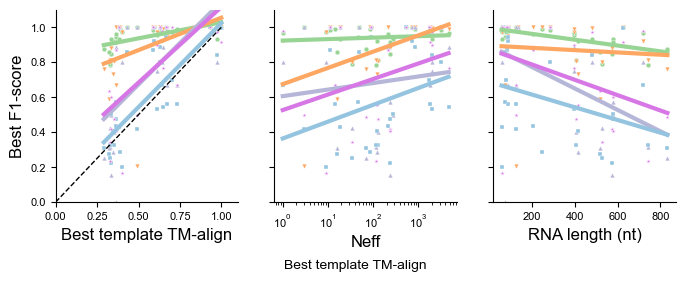

In [10]:
from sklearn.linear_model import LinearRegression

fig, axes = plt.subplots(1,3,figsize=(8,2.5),sharey=True)

variables = ['template_tm', 'neff', 'rna_length']
labels = ['Best template TM-align','Neff','RNA length (nt)']

axes[0].plot([0, 1], [0, 1], linestyle='--', color='black',linewidth=1)
score = 'bp'
k=0
colors = [cm.get_cmap(c)(0.4) for c in ['Greens', 'Oranges', 'Purples','Blues']]
for score,k,m in zip(['bp','crossed','singlet','nc','motif'],colors+['#d777e6'],['o','v','^','s','*']): # '*'
    for i in range(3):
        to_plot = best_pred[~best_pred.index.isin(no_present[score])].copy()
        g=sns.scatterplot(to_plot,x=variables[i],y=score,ax=axes[i],c=k,s=12,marker=m)
                    #hue='template_tm',size='template_tm',palette='turbo',legend=i==1) # 
        axes[i].set_ylim(0,1.1)
        axes[i].set_xlabel(labels[i],size=12)
        axes[i].set_ylabel('Best F1-score',size=12)
        axes[i].tick_params(axis='both', which='major', labelsize=8) 
        axes[i].spines[['right', 'top']].set_visible(False)
        #if i==1: axes[i].get_legend().remove()
    
        # Linear Regression and plotting
        X = to_plot[[variables[i]]]
        if i == 1:
            X = np.log10(X)
        y = to_plot[score]
        nan_indices = np.where(np.isnan(y))[0]
        #print('i',nan
        X = np.delete(X, nan_indices, axis=0)
        y = np.delete(y, nan_indices)
        model = LinearRegression().fit(X, y)
        
        r2 = model.score(X, y)
        X_subset = np.array([X.min().item(),X.max().item()]).reshape(-1, 1)
        predicted = model.predict(X_subset)
        if i==1:
            X_subset = np.array([1,10**X_subset[1]])
            print(i,X_subset)
            print(predicted)
        axes[i].plot(X_subset,predicted, color=k,linestyle='-', linewidth=3)  # Line of best fit
        
        #axes[i].text(0.95, 0.1, f'$R^2$ = {r2:.2f}', transform=axes[i].transAxes,
        #             ha='right', va='top', fontsize=8)  # R-squared value
        if i == 1:  # Apply log10 scale to the x-axis of the 3rd plot
            axes[i].set_xscale('log')
axes[0].set_xlim(0,1.1)
handles, labels = axes[1].get_legend_handles_labels()  #handles and labels are now in order
legend = fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, -0.08), ncol=5, fontsize=8, title='Best template TM-align',title_fontsize=10,frameon=False)

'''
# Fit linear model with first two variables
best_pred['neff_log10'] = best_pred.neff.apply(np.log10)
X = best_pred[['template_tm', 'neff_log10']]
y = best_pred[score]
model = LinearRegression().fit(X, y)
r2 = model.score(X, y)
coefficients = model.coef_
intercept = model.intercept_
equation = f"Best predicted TM-align = {coefficients[0]:.2f} × Best template TM-align + {coefficients[1]:.3f} × log(Neff) + {intercept:.2f}    [$R^2$ = {r2:.2f}]"
axes[0].text(0.05, 1.3, equation, fontsize=10, va='top')
'''


plt.savefig(f"figure_subpanels/casp16_secstruct_summ.png",dpi=400, bbox_inches='tight', transparent=True)
plt.savefig(f"figure_subpanels/casp16_secstruct_summ.svg",dpi=400, bbox_inches='tight', transparent=True)

# think about msa v no msa

In [27]:
af3_wo_complex = preds_top1[preds_top1.group.str.contains('998')].sort_values('target').reset_index()
af3_wo_complex_msa = preds_top1[preds_top1.group.str.contains('999')].sort_values('target').reset_index()
af3_304 = preds_top1[preds_top1.group.str.contains('304')].sort_values('target').reset_index()

In [30]:
af3_wo_complex.head()

,index,target,group,f1_bp_list,recall_bp_list,precision_bp_list,recall_singlets_as_bp,f1_singlet,f1_crossed
0,1,R1203,AF3 w/o complex - S 998,0.967033,1.000000,0.936170,1.000000,0.666667,1.000000
1,64,R1205,AF3 w/o complex - S 998,0.648649,0.666667,0.631579,0.333333,0.500000,0.648649
2,126,R1209,AF3 w/o complex - S 998,0.867925,0.884615,0.851852,0.000000,0.000000,0.000000
3,192,R1211,AF3 w/o complex - S 998,0.985507,0.971429,1.000000,0.000000,0.000000,NaN
4,256,R1212,AF3 w/o complex - S 998,0.853333,0.761905,1.000000,0.000000,NaN,1.000000


In [56]:
af3_wo_complex['f1_bp_list_304'] =  af3_304.f1_bp_list -  af3_wo_complex.f1_bp_list
af3_wo_complex['f1_bp_list_perc_304'] =  100*(af3_304.f1_bp_list -  af3_wo_complex.f1_bp_list)/ af3_wo_complex.f1_bp_list
af3_wo_complex['f1_bp_list_msa'] = af3_wo_complex.f1_bp_list -  af3_wo_complex_msa.f1_bp_list
af3_wo_complex['f1_bp_list_perc_msa'] =  100*(af3_wo_complex.f1_bp_list -  af3_wo_complex_msa.f1_bp_list)/ af3_wo_complex_msa.f1_bp_list


In [48]:
af3_wo_complex['neff'] = af3_wo_complex.target.map(CASP16_NEFF)
af3_wo_complex['logneff'] = af3_wo_complex.neff.apply(np.log10)

af3_wo_complex['template'] = af3_wo_complex.target.map(CASP16_TEMPLATE_DICT)

/tmp/ipykernel_8133/1095496364.py:2: UserWarning: FixedFormatter should only be used together with FixedLocator
  t=g.set_xticklabels(labels=g.get_xticklabels(),rotation = 90)


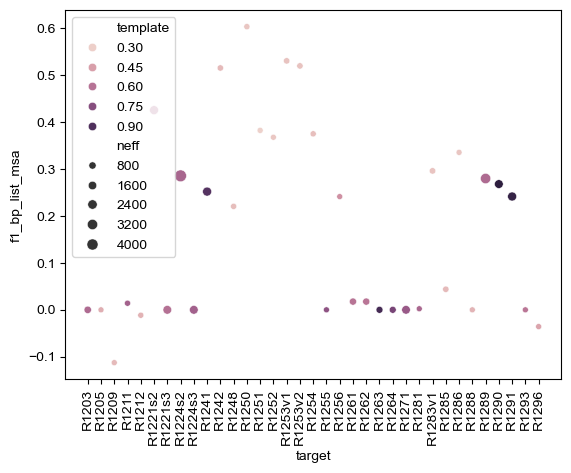

In [47]:
g = sns.scatterplot(af3_wo_complex,x='target',y='f1_bp_list_msa',hue='template',size='neff')
t=g.set_xticklabels(labels=g.get_xticklabels(),rotation = 90)

/tmp/ipykernel_8133/3482117361.py:2: UserWarning: FixedFormatter should only be used together with FixedLocator
  t=g.set_xticklabels(labels=g.get_xticklabels(),rotation = 90)


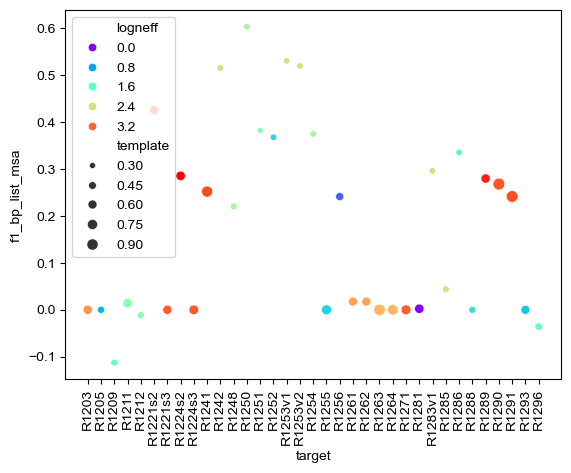

In [53]:
g = sns.scatterplot(af3_wo_complex,x='target',y='f1_bp_list_msa',size='template',hue='logneff',palette='rainbow')
t=g.set_xticklabels(labels=g.get_xticklabels(),rotation = 90)
# plot percent improvement instead?

/tmp/ipykernel_8133/2592753872.py:2: UserWarning: FixedFormatter should only be used together with FixedLocator
  t=g.set_xticklabels(labels=g.get_xticklabels(),rotation = 90)


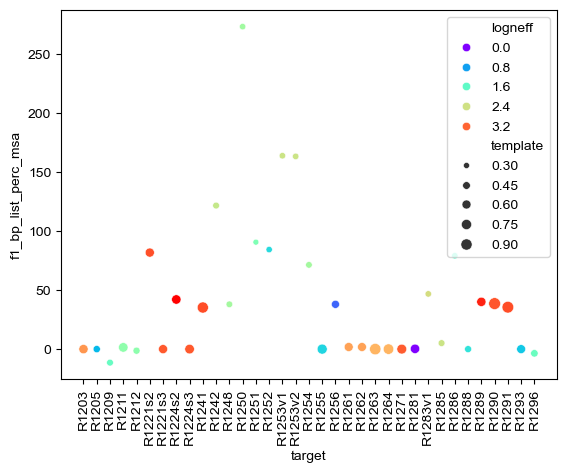

In [57]:
g = sns.scatterplot(af3_wo_complex,x='target',y='f1_bp_list_perc_msa',size='template',hue='logneff',palette='rainbow')
t=g.set_xticklabels(labels=g.get_xticklabels(),rotation = 90)
# plot percent improvement instead?

/tmp/ipykernel_8133/2454510474.py:2: UserWarning: FixedFormatter should only be used together with FixedLocator
  t=g.set_xticklabels(labels=g.get_xticklabels(),rotation = 90)


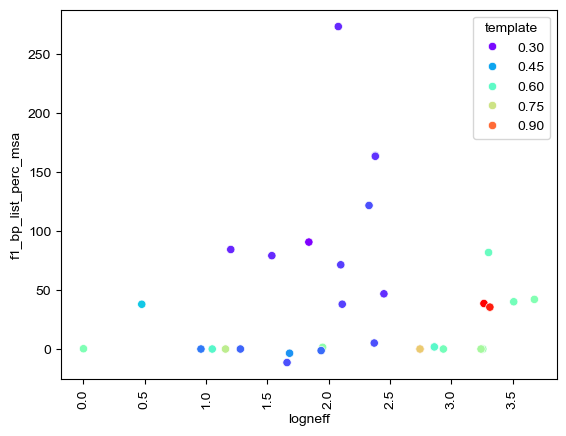

In [59]:
g = sns.scatterplot(af3_wo_complex,x='logneff',y='f1_bp_list_perc_msa',hue='template',palette='rainbow')
t=g.set_xticklabels(labels=g.get_xticklabels(),rotation = 90)
# plot percent improvement instead?

/tmp/ipykernel_8133/3592636023.py:2: UserWarning: FixedFormatter should only be used together with FixedLocator
  t=g.set_xticklabels(labels=g.get_xticklabels(),rotation = 90)


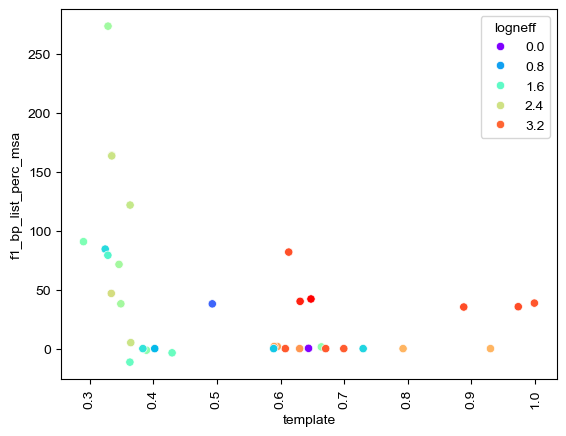

In [60]:
g = sns.scatterplot(af3_wo_complex,x='template',y='f1_bp_list_perc_msa',hue='logneff',palette='rainbow')
t=g.set_xticklabels(labels=g.get_xticklabels(),rotation = 90)
# plot percent improvement instead?

/tmp/ipykernel_8133/2400130172.py:2: UserWarning: FixedFormatter should only be used together with FixedLocator
  t=g.set_xticklabels(labels=g.get_xticklabels(),rotation = 90)


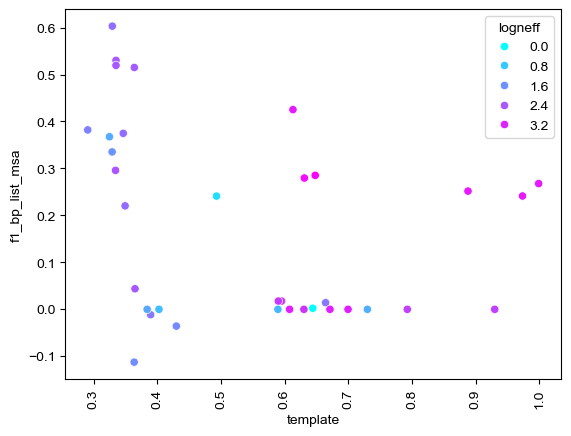

In [65]:
g = sns.scatterplot(af3_wo_complex,x='template',y='f1_bp_list_msa',hue='logneff',palette='cool')
t=g.set_xticklabels(labels=g.get_xticklabels(),rotation = 90)
# plot percent improvement instead?

# when there is a remplate, only those with very large MSAs benefit from MSA information, but without template, MSA information is utalized
# but poor correlation with msa depth by rmas --> different msa depth and/ors sizes is sufficient

<Axes: xlabel='target', ylabel='f1_bp_list_304'>

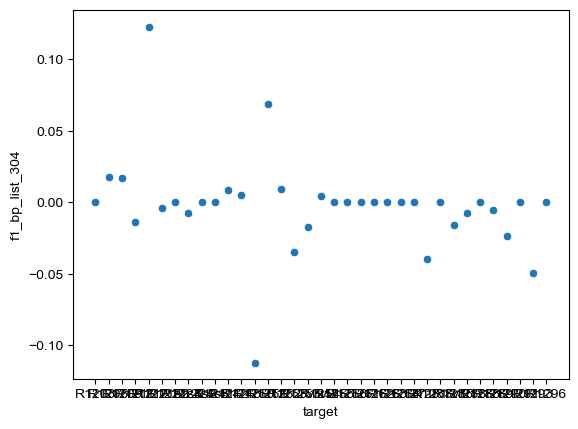

In [34]:
sns.scatterplot(af3_wo_complex,x='target',y='f1_bp_list_304')

# Old

In [ ]:
df_summed = get_group_score(combined, agg="mean", score="score",targets_to_choose_best=TARGETS_CHOOSE_BEST,
            group_col='group_motif',fill_nan=np.nan,fill_not_present=0,target_col='target')
df_summed[['group','motif_type']] = df_summed.group_motif.str.split('|', n=1,expand=True)
sum_group = df_summed.groupby('group').F1.sum()
df_summed['F1_norm'] = df_summed.apply(lambda row: row.F1 * group_score.loc[row.group] / sum_group.loc[row.group], axis=1)

/tmp/ipykernel_201456/1820348143.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = [cm.get_cmap(c)(0.4) for c in ['Greens', 'Oranges', 'Purples']]
/home/rachael/Desktop/CASP/CASP16_Das_internal/NA_assessment/analysis/CASP16_NA_assessment.py:1029: UserWarning: FixedFormatter should only be used together with FixedLocator
  t=ax.set_yticklabels(labels=ax.get_yticklabels(),rotation = yrot,size=ticklabel_size)
/home/rachael/Desktop/CASP/CASP16_Das_internal/NA_assessment/analysis/CASP16_NA_assessment.py:1030: UserWarning: FixedFormatter should only be used together with FixedLocator
  t=ax.set_xticklabels(labels=ax.get_xticklabels(),rotation = 0,size=ticklabel_size+1)
/home/rachael/Desktop/CASP/CASP16_Das_internal/NA_assessment/analysis/CASP16_NA_assessment.py:1029: UserWarning: FixedFormatter should only be u

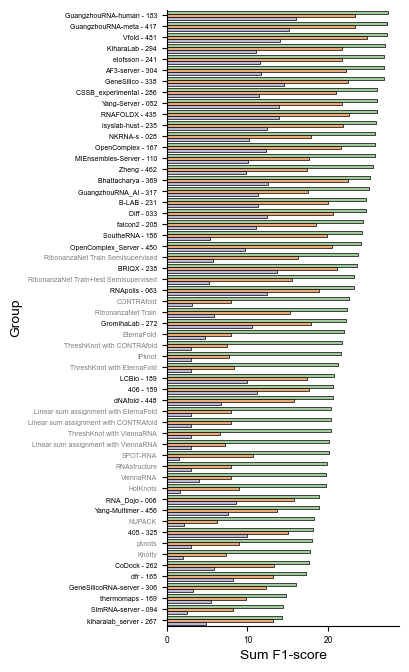

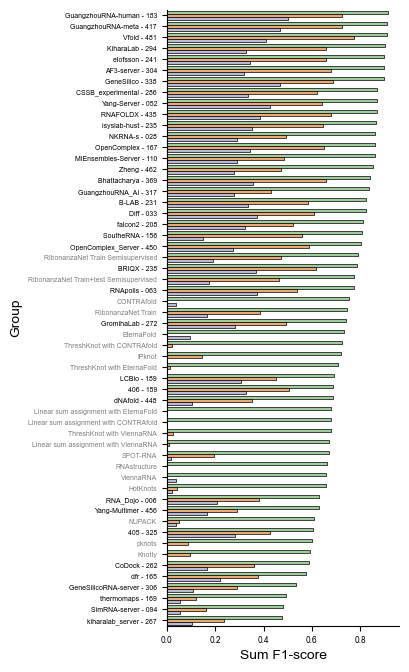

In [8]:

scores = ['f1_bp_list', 'f1_crossed','f1_singlet' ]

colors = [cm.get_cmap(c)(0.4) for c in ['Greens', 'Oranges', 'Purples']]

for rank_type in ['mean']: # 'sum', 'sum',
    plot_barplot_SS(preds_top1,scores,palette=colors,figsize=(3,8),
                y_highlight=ss_names.values(),
                save=f'figure_subpanels/barplot_all_ss_{rank_type}',
                   rank_type=rank_type)

/home/rachael/Desktop/CASP/CASP16_Das_internal/NA_assessment/analysis/CASP16_NA_assessment.py:1029: UserWarning: FixedFormatter should only be used together with FixedLocator
  t=ax.set_yticklabels(labels=ax.get_yticklabels(),rotation = yrot,size=ticklabel_size)
/home/rachael/Desktop/CASP/CASP16_Das_internal/NA_assessment/analysis/CASP16_NA_assessment.py:1030: UserWarning: FixedFormatter should only be used together with FixedLocator
  t=ax.set_xticklabels(labels=ax.get_xticklabels(),rotation = 0,size=ticklabel_size+1)
/home/rachael/Desktop/CASP/CASP16_Das_internal/NA_assessment/analysis/CASP16_NA_assessment.py:1029: UserWarning: FixedFormatter should only be used together with FixedLocator
  t=ax.set_yticklabels(labels=ax.get_yticklabels(),rotation = yrot,size=ticklabel_size)
/home/rachael/Desktop/CASP/CASP16_Das_internal/NA_assessment/analysis/CASP16_NA_assessment.py:1030: UserWarning: FixedFormatter should only be used together with FixedLocator
  t=ax.set_xticklabels(labels=ax.get_

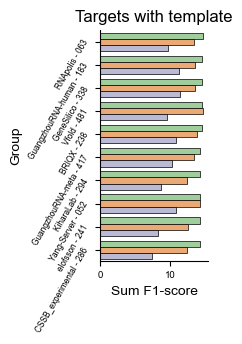

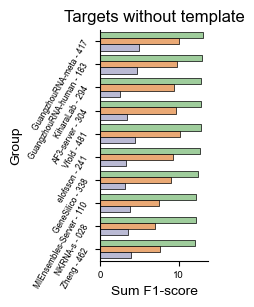

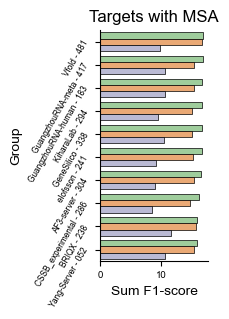

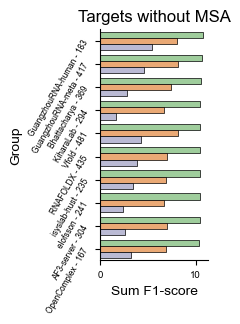

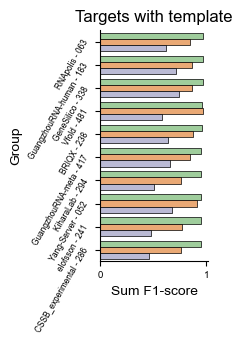

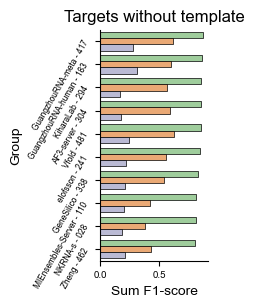

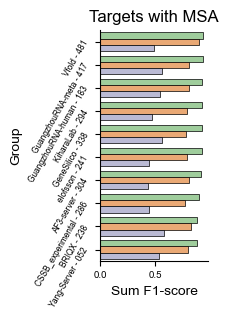

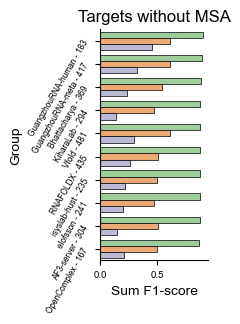

In [10]:
N=10
for rank_type in ['sum','mean']: 

    # template
    plot_barplot_SS(preds_top1[preds_top1.target.isin(TEMPLATE_TARGETS)],scores,palette=colors,
             figsize=(1.4,3),top_N=N,yrot=60,
            y_highlight=ss_names.values(),
            ticklabel_size=6,title='Targets with template',
            save=f'figure_subpanels/barplot_template_ss_{rank_type}',
               rank_type=rank_type)
    plot_barplot_SS(preds_top1[preds_top1.target.isin(NO_TEMPLATE_TARGETS)],scores,palette=colors,
             figsize=(1.4,3),top_N=N,yrot=60,
            y_highlight=ss_names.values(),
            ticklabel_size=6,title='Targets without template',
            save=f'figure_subpanels/barplot_notemplate_ss_{rank_type}',
               rank_type=rank_type)

    # msa
    plot_barplot_SS(preds_top1[preds_top1.target.isin(MSA_TARGETS)],scores,palette=colors,
             figsize=(1.4,3),top_N=N,y_highlight=ss_names.values(),yrot=60,
            ticklabel_size=6,title='Targets with MSA',
            save=f'figure_subpanels/barplot_msa_ss_{rank_type}',
               rank_type=rank_type)
    plot_barplot_SS(preds_top1[preds_top1.target.isin(NO_MSA_TARGETS)],scores,palette=colors,
             figsize=(1.4,3),top_N=N,y_highlight=ss_names.values(),yrot=60,
            ticklabel_size=6,title='Targets without MSA',
            save=f'figure_subpanels/barplot_nomsa_ss_{rank_type}',
               rank_type=rank_type)


# OLD

In [ ]:


# remove groups with too low paricipation for the ranking and plots
pivot_df = preds_top1.pivot(index='group', columns='target', values='f1_bp_list')
mask = pivot_df.isnull()
participation = 1-(mask.sum(axis=1) / len(mask.columns))
groups_to_drop = pivot_df[participation <= PARTICIPATION_RATE].index
print(groups_to_drop)
# TODO note this also kicks off some secondary structure predictors, should we just leave those out of the methods??
# progress, swapping to asking Thomas about this problem
# TODO check this is the same groups getting dropping across all monomer analysis

msa_info = {'less':{},'more':{}}
for neff_boundary in [1,2,4,3.,10]:
    msa_info['less'][neff_boundary] = TARGET_INFO[TARGET_INFO['MSA Neff']<=neff_boundary].Target.to_list()
    msa_info['more'][neff_boundary] = TARGET_INFO[TARGET_INFO['MSA Neff']>neff_boundary].Target.to_list()
# with 1 there were only 8 targets, many very similiar, so instead use 2 which is more even number 15:20
print({n:len(l) for n,l in msa_info['less'].items()})
print({n:len(l) for n,l in msa_info['more'].items()})

template_info = TEMPLATE_INFO[TEMPLATE_INFO.Competition == 'CASP16']
templates = template_info[template_info['Best Template TM align']>0.45].Target.to_list()
notemplates = template_info[template_info['Best Template TM align']<=0.45].Target.to_list()
print(len(templates),len(notemplates))

In [ ]:
# comparing sum norm and nan mean
# scores = f1_bp_list	recall_bp_list	precision_bp_list	f1_singlet	f1_crossed	recall_singlets_as_bp



to_plot = preds_top1[~preds_top1.group.isin(groups_to_drop)].copy()
to_plot_reduced = reduce_score_list_overlapping_target_df(to_plot, direction='max')
ss_tables = {}
# only used for normalization of pure sum
targets_participating = {'f1_bp_list': [target for target,bp in native_bp_lists.items() if any([len(x)>0 for x in bp]) and target in preds_top1.target.unique()],
                            'f1_crossed': [target for target,crossed in native_crosspairs.items() if any([len(x)>0 for x in crossed]) and target in preds_top1.target.unique()],
                            'f1_singlet': [target for target,singlets in native_singlets.items() if any([len(x)>0 for x in singlets]) and target in preds_top1.target.unique()]}
#correct for the ones we are ranking together
for n,targets in targets_participating.items():
    for t_list in MONOMER_TARGETS_CHOOSE_BEST:
        overlap = [x for x in t_list if x in targets]
        if len(overlap)>1:
            for x in overlap[1:]:
                targets.remove(x)
for score in ['f1_bp_list','f1_crossed','f1_singlet']:

    # sort values by sum of scores, giving perfect to the case when there is no motif and the y predicted none


    
    rank_order_sum_nan_one = (to_plot_reduced.groupby('group')
            .apply(lambda x: x[score].fillna(1).sum())  # Replace NaN with 1 and then sum
            .reset_index(name='total_score').sort_values('total_score', ascending=False))
    rank_order = rank_order_sum_nan_one['group'].values
    to_plot['gr_code'] = pd.Categorical(to_plot['group'],ordered=True,categories=rank_order)

    # make table
    table = to_plot.pivot_table(index="gr_code",columns="target",values=score, dropna=False,fill_value=0) 
    # fill 0, so if not participate get 0 score, this differentiate between correctly predicting no motif (nan)
    # and not participating (0)
    # Replace 0 with NaN if there was a NaN in the original data for that group-target combination
    for col in preds_top1['target'].unique():
        # Check if there are any NaNs in the original groups for the specific target
        groups_with_nan = preds_top1[(preds_top1['target'] == col) & (preds_top1[score].isna())]['group']
        # Set 0s in the table to NaN for those groups that had NaNs for this target
        for group in groups_with_nan:
            if group in table.index:
                table.loc[group, col] = table.loc[group, col] if pd.isna(table.loc[group, col]) else np.nan

    # add in the sum norm
    max_score = len(to_plot_reduced.target.unique())
    min_score = max_score - len(targets_participating[score])

    rank_order_sum_nan_one['sum_norm']= (rank_order_sum_nan_one.total_score-min_score) / (max_score-min_score)
    rank_order_nan_mean = (to_plot_reduced.groupby('group')
            .apply(lambda x: x[score].mean(skipna=True))
            .reset_index(name='mean_score'))
    # add total scores
    table = table.reset_index().merge(rank_order_sum_nan_one[['group', 'sum_norm']], left_on='gr_code', right_on='group', how='left')
    table = table.merge(rank_order_nan_mean, left_on='group', right_on='group', how='left')

    # Add ranks 
    table['sum_norm_rank'] = table['sum_norm'].rank(ascending=False, method='min')
    table['mean_score_rank'] = table['mean_score'].rank(ascending=False, method='min')
    table = table.drop(columns='group')

    # save total scores and rank for the template and msa grouped targets
    grouped_df = {'template': reduce_score_list_overlapping_target_df(to_plot[to_plot.target.isin(templates)], direction='max'),
                  'notemplate': reduce_score_list_overlapping_target_df(to_plot[to_plot.target.isin(notemplates)], direction='max'),
                  'msa':  reduce_score_list_overlapping_target_df(to_plot[to_plot.target.isin(msa_info['more'][2])], direction='max'),
                  'nomsa': reduce_score_list_overlapping_target_df(to_plot[to_plot.target.isin(msa_info['less'][2])], direction='max')}

    for grouping, grdf in grouped_df.items():
        nan_mean = (grdf.groupby('group')
                .apply(lambda x: x[score].mean(skipna=True))
                .reset_index(name=f'{grouping}_mean_score'))
        
        sum_nan_one = (grdf.groupby('group')
            .apply(lambda x: x[score].fillna(1).sum())  # Replace NaN with 1 and then sum
            .reset_index(name=f'{grouping}_sum_norm'))     
        
        max_score = len(grdf.target.unique())
        min_score = max_score - len([ x for x in  targets_participating[score] if x in grdf.target.unique()])
        sum_nan_one[f'{grouping}_sum_norm']= (sum_nan_one[f'{grouping}_sum_norm']-min_score) / (max_score-min_score)
        
        # add to table, also add in rank
        table = table.merge(sum_nan_one[['group', f'{grouping}_sum_norm']], left_on='gr_code', right_on='group', how='left')
        table = table.merge(nan_mean, left_on='group', right_on='group', how='left')
        table[f'{grouping}_sum_norm_rank'] = table[f'{grouping}_sum_norm'].rank(ascending=False, method='min')
        table[f'{grouping}_mean_score_rank'] = table[f'{grouping}_mean_score'].rank(ascending=False, method='min')
        table = table.drop(columns='group')

    ss_tables[score] = table


In [ ]:
reduce_score_list_overlapping_target_df(to_plot[to_plot.target.isin(TEMPLATE_TARGETS)], direction='max')

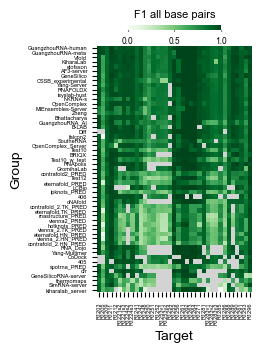

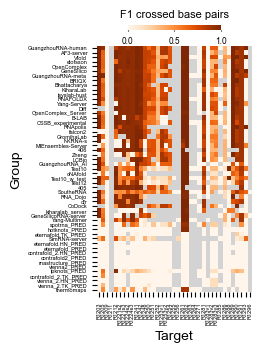

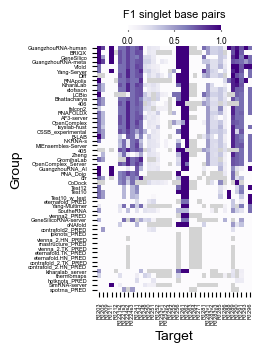

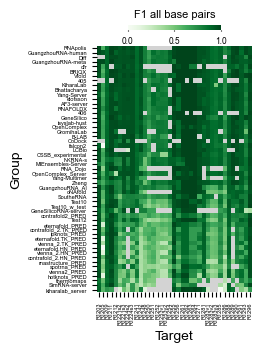

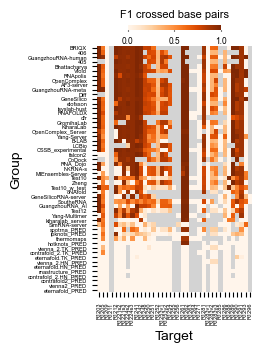

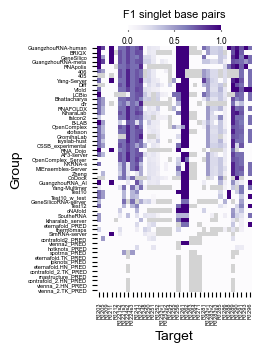

In [18]:
for rank_type in ['sum_norm','mean']: # 'sum',
    plot_heatmap_SS(preds_top1[~(preds_top1.group.isin(groups_to_drop))],'f1_bp_list',
                 figsize=(2,4),cmap='Greens',y_highlight=ss_names.values(),
                cbar_label='F1 all base pairs',ticklabel_size=4,
                save=f'figure_subpanels/heatmap_f1_all_base_pairs_{rank_type}',
                    rank_type=rank_type)
    plot_heatmap_SS(preds_top1[(~(preds_top1.group.isin(groups_to_drop)))],
                 'f1_crossed',figsize=(2,4),cmap='Oranges',y_highlight=ss_names.values(),
                cbar_label='F1 crossed base pairs',ticklabel_size=4,
                save=f'figure_subpanels/heatmap_f1_crossed_base_pairs_{rank_type}',
                    rank_type=rank_type)
    plot_heatmap_SS(preds_top1[(~(preds_top1.group.isin(groups_to_drop))) ],
                 'f1_singlet',figsize=(2,4),cmap='Purples',y_highlight=ss_names.values(),
                cbar_label='F1 singlet base pairs',ticklabel_size=4,
                save=f'figure_subpanels/heatmap_f1_singlet_base_pairs_{rank_type}',
                    rank_type=rank_type)